# Datathon — Passos Mágicos

### Análise dos indicadores educacionais | 2022–2024

Este notebook apresenta a preparação, análise exploratória e modelagem
preditiva dos dados disponibilizados para o Datathon Case Passos Mágicos.

O trabalho contempla as três bases anuais, análises longitudinais,
investigação dos indicadores educacionais e desenvolvimento de um modelo
exploratório para identificação antecipada do risco de defasagem.

## **1. Preparação dos dados**

### 1.1 Importação das bibliotecas

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

sns.set_theme(style="whitegrid")

### 1.2 Carregamento da base de dados

In [2]:
# Upload do arquivo Excel no Google Colab

from google.colab import files
import os

NOME_ARQUIVO = "BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

if os.path.exists(NOME_ARQUIVO):
    print(f"Arquivo já disponível: {NOME_ARQUIVO}")

else:
    print("Faça o upload do arquivo Excel:")
    uploaded = files.upload()

    if NOME_ARQUIVO not in uploaded:
        raise FileNotFoundError(
            f"O arquivo esperado é: {NOME_ARQUIVO}"
        )

ARQUIVO = NOME_ARQUIVO

print(f"\nArquivo utilizado: {ARQUIVO}")

excel = pd.ExcelFile(ARQUIVO)
print("Abas encontradas:", excel.sheet_names)

df_2022 = pd.read_excel(ARQUIVO, sheet_name="PEDE2022")
df_2023 = pd.read_excel(ARQUIVO, sheet_name="PEDE2023")
df_2024 = pd.read_excel(ARQUIVO, sheet_name="PEDE2024")

print(f"2022: {df_2022.shape[0]} linhas x {df_2022.shape[1]} colunas")
print(f"2023: {df_2023.shape[0]} linhas x {df_2023.shape[1]} colunas")
print(f"2024: {df_2024.shape[0]} linhas x {df_2024.shape[1]} colunas")

Arquivo já disponível: BASE DE DADOS PEDE 2024 - DATATHON.xlsx

Arquivo utilizado: BASE DE DADOS PEDE 2024 - DATATHON.xlsx
Abas encontradas: ['PEDE2022', 'PEDE2023', 'PEDE2024']
2022: 860 linhas x 42 colunas
2023: 1014 linhas x 48 colunas
2024: 1156 linhas x 50 colunas


In [3]:
display(df_2022.head())
display(df_2023.head())
display(df_2024.head())

,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,INDE 22,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Rec Av3,Avaliador4,Rec Av4,IAA,IEG,IPS,Rec Psicologia,IDA,Matem,Portug,Inglês,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,Ametista,Quartzo,5.78,753,18,10,4,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,8.30,4.10,5.60,Requer avaliação,4.00,2.70,3.50,6.00,Sim,Não,7.28,5.00,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,Ametista,Ametista,7.05,469,8,3,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,8.80,5.20,6.30,Sem limitações,6.80,6.30,4.50,9.70,Não,Não,6.78,10.00,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,Ametista,Ágata,6.59,629,13,6,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,0.00,7.90,5.60,Sem limitações,5.60,5.80,4.00,6.90,Não,Não,7.56,10.00,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...
3,RA-4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Ametista,Ametista,Quartzo,5.95,731,15,7,4,Avaliador-5,Promovido de Fase,Avaliador-27,Mantido na Fase atual,Avaliador-28,Mantido na Fase atual,Avaliador-31,Mantido na Fase atual,8.80,4.50,5.60,Requer avaliação,5.00,2.80,3.50,8.70,Não,Não,5.28,10.00,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
4,RA-5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,Ametista,Ametista,7.43,344,6,2,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,7.90,8.60,5.60,Requer avaliação,5.20,7.00,2.90,5.70,Não,Não,7.39,10.00,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...


,RA,Fase,INDE 2023,Pedra 2023,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,Pedra 23,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Rec Av3,Avaliador4,Rec Av4,IAA,IEG,IPS,IPP,Rec Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Destaque IPV.1
0,RA-861,ALFA,9.31,Topázio,ALFA A - G0/G1,Aluno-861,6/17/2015,8,Feminino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,9.50,10.00,8.13,8.44,NaN,9.60,9.80,9.40,NaN,NaN,NaN,8.92,10.00,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
1,RA-862,ALFA,8.22,Topázio,ALFA A - G0/G1,Aluno-862,5/31/2014,9,Masculino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,8.50,9.10,8.14,7.50,NaN,8.90,8.50,9.20,NaN,NaN,NaN,8.59,5.00,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,NaN
2,RA-863,ALFA,5.93,Quartzo,ALFA A - G0/G1,Aluno-863,2/25/2016,7,Masculino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,0.00,7.60,3.14,5.94,NaN,6.30,7.00,5.50,NaN,NaN,NaN,6.26,10.00,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
3,RA-864,ALFA,7.03,Ametista,ALFA A - G0/G1,Aluno-864,2015-12-03 00:00:00,1900-01-08 00:00:00,Feminino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,0.00,7.60,8.14,7.50,NaN,6.30,7.00,5.50,NaN,NaN,NaN,8.50,10.00,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
4,RA-865,ALFA,8.16,Topázio,ALFA A - G0/G1,Aluno-865,11/13/2014,8,Masculino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,8.50,8.70,7.52,7.50,NaN,7.40,7.30,7.50,NaN,NaN,NaN,7.92,10.00,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN


,RA,Fase,INDE 2024,Pedra 2024,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,Pedra 23,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Avaliador4,Avaliador5,Avaliador6,IAA,IEG,IPS,IPP,Rec Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Ativo/ Inativo.1
0,RA-1275,ALFA,7.61,Ametista,ALFA A - G0/G1,Aluno-1275,2016-07-28,8,Masculino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,10.00,8.67,6.26,5.62,NaN,8.00,10.00,6.00,NaN,NaN,NaN,5.45,10.00,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
1,RA-1276,ALFA,8.00,Topázio,ALFA A - G0/G1,Aluno-1276,2016-10-16,8,Feminino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,10.00,9.33,3.76,7.50,NaN,8.00,10.00,6.00,NaN,NaN,NaN,7.05,10.00,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
2,RA-1277,ALFA,7.95,Ametista,ALFA A - G0/G1,Aluno-1277,2016-08-16,8,Masculino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,10.00,9.08,3.76,7.50,NaN,8.00,10.00,6.00,NaN,NaN,NaN,7.05,10.00,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Dom Pedro Villas Boas de Souza,Cursando,Cursando
3,RA-868,ALFA,7.16,Ametista,ALFA A - G0/G1,Aluno-868,2015-11-08,8,Masculino,2023,Pública,NaN,NaN,NaN,Topázio,NaN,8.64,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,8.00,9.75,3.76,6.88,NaN,7.00,8.00,6.00,NaN,NaN,NaN,7.21,5.00,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
4,RA-1278,ALFA,5.44,Quartzo,ALFA A - G0/G1,Aluno-1278,2015-03-22,9,Masculino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,9.00,4.17,3.76,5.00,NaN,7.50,8.00,7.00,NaN,NaN,NaN,4.17,5.00,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EM Etelvina Delfim Simões,Cursando,Cursando


In [4]:
for ano, base in [(2022, df_2022), (2023, df_2023), (2024, df_2024)]:
    print(f"\n--- COLUNAS {ano} ---")
    print(base.columns.tolist())


--- COLUNAS 2022 ---
['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV']

--- COLUNAS 2023 ---
['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado', 'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase Ideal', 'Defasagem', 'Des

### 1.3 Padronização e consolidação

In [5]:
for ano, base in [(2022, df_2022), (2023, df_2023), (2024, df_2024)]:
    print(f"Ano {ano}")
    print("Registros:", len(base))
    print("Alunos distintos:", base["RA"].nunique())
    print("RA duplicado:", base["RA"].duplicated().sum())
    print("-" * 40)

Ano 2022
Registros: 860
Alunos distintos: 860
RA duplicado: 0
----------------------------------------
Ano 2023
Registros: 1014
Alunos distintos: 1014
RA duplicado: 0
----------------------------------------
Ano 2024
Registros: 1156
Alunos distintos: 1156
RA duplicado: 0
----------------------------------------


In [6]:
# Valores ausentes. Não serão preenchidas automaticamente valores ausentes com zero, pois ausência de avaliação não significa nota zero.

def analisar_nulos(base, ano):
    resultado = pd.DataFrame({
        "Nulos": base.isna().sum(),
        "Percentual (%)": (base.isna().mean() * 100).round(2)
    }).sort_values("Percentual (%)", ascending=False)

    print(f"Valores ausentes — {ano}")
    display(resultado[resultado["Nulos"] > 0])

for ano, base in [(2022, df_2022), (2023, df_2023), (2024, df_2024)]:
    analisar_nulos(base, ano)

Valores ausentes — 2022


,Nulos,Percentual (%)
Inglês,577,67.09
Rec Av4,564,65.58
Avaliador4,550,63.95
Pedra 20,537,62.44
Pedra 21,398,46.28
Avaliador3,326,37.91
Matem,2,0.23
Portug,2,0.23


Valores ausentes — 2023


,Nulos,Percentual (%)
Pedra 23,1014,100.00
Rec Psicologia,1014,100.00
Indicado,1014,100.00
Atingiu PV,1014,100.00
Destaque IEG,1014,100.00
Destaque IDA,1014,100.00
Destaque IPV,1014,100.00
Destaque IPV.1,1014,100.00
Rec Av2,1014,100.00
Rec Av3,1014,100.00


Valores ausentes — 2024


,Nulos,Percentual (%)
Cg,1156,100.00
Cf,1156,100.00
Atingiu PV,1156,100.00
Indicado,1156,100.00
Destaque IEG,1156,100.00
Rec Psicologia,1156,100.00
Rec Av1,1156,100.00
Rec Av2,1156,100.00
Destaque IPV,1156,100.00
Destaque IDA,1156,100.00


In [7]:
# Padronização - existem diferenças de nomenclatura entre os anos. O IPP não existe na aba de 2022 e permanecerá ausente nesse ano.

def padronizar_base(base, ano):
    df_temp = base.copy()

    # Colunas cujo nome pode ser padronizado diretamente
    mapa = {
        "Idade 22": "Idade",
        "Nome Anonimizado": "Nome",
        "Data de Nasc": "Data_Nasc",
        "Matem": "Mat",
        "Portug": "Por",
        "Inglês": "Ing",
        "Fase ideal": "Fase_Ideal",
        "Fase Ideal": "Fase_Ideal",
        "Defas": "Defasagem"
    }

    df_temp = df_temp.rename(
        columns={k: v for k, v in mapa.items() if k in df_temp.columns}
    )

    # INDE do ano corrente
    if ano == 2022:
        df_temp["INDE"] = pd.to_numeric(df_temp["INDE 22"], errors="coerce")
    elif ano == 2023:
        df_temp["INDE"] = pd.to_numeric(df_temp["INDE 2023"], errors="coerce")
    elif ano == 2024:
        df_temp["INDE"] = pd.to_numeric(df_temp["INDE 2024"], errors="coerce")

    df_temp["Ano"] = ano
    return df_temp

df22 = padronizar_base(df_2022, 2022)
df23 = padronizar_base(df_2023, 2023)
df24 = padronizar_base(df_2024, 2024)

print("Padronização concluída.")

Padronização concluída.


In [8]:
# conversão dos indicadores para formato numérico

INDICADORES = ["INDE", "IAA", "IEG", "IPS", "IPP", "IDA", "IPV", "IAN"]

for base in [df22, df23, df24]:
    for coluna in INDICADORES + ["Defasagem", "Idade", "Ano ingresso"]:
        if coluna in base.columns:
            base[coluna] = pd.to_numeric(base[coluna], errors="coerce")

In [9]:
# Consolidação de 2022, 2023 e 2024

df = pd.concat([df22, df23, df24], ignore_index=True, sort=False)

print("Dimensão da base consolidada:", df.shape)
display(
    df[["RA", "Ano", "Fase", "INDE", "IAA", "IEG",
        "IPS", "IPP", "IDA", "IPV", "IAN", "Defasagem"]].head()
)

Dimensão da base consolidada: (3030, 58)


,RA,Ano,Fase,INDE,IAA,IEG,IPS,IPP,IDA,IPV,IAN,Defasagem
0,RA-1,2022,7,5.78,8.30,4.10,5.60,NaN,4.00,7.28,5.00,-1
1,RA-2,2022,7,7.05,8.80,5.20,6.30,NaN,6.80,6.78,10.00,0
2,RA-3,2022,7,6.59,0.00,7.90,5.60,NaN,5.60,7.56,10.00,0
3,RA-4,2022,7,5.95,8.80,4.50,5.60,NaN,5.00,5.28,10.00,0
4,RA-5,2022,7,7.43,7.90,8.60,5.60,NaN,5.20,7.39,10.00,0


In [10]:
# validação da base consolidada

print("Registros por ano:")
display(df["Ano"].value_counts().sort_index())

print("Alunos distintos por ano:")
display(df.groupby("Ano")["RA"].nunique())

Registros por ano:


,count
Ano,
2022,860
2023,1014
2024,1156


Alunos distintos por ano:


,RA
Ano,
2022,860
2023,1014
2024,1156


## **2. Análise Exploratória**

### 2.1 Perfil geral dos alunos

In [11]:
perfil = df.groupby("Ano").agg(
    Registros=("RA", "size"),
    Alunos_distintos=("RA", "nunique"),
    Idade_media=("Idade", "mean")
).round(2)

display(perfil)

,Registros,Alunos_distintos,Idade_media
Ano,,,
2022,860,860,12.14
2023,1014,1014,12.29
2024,1156,1156,12.99


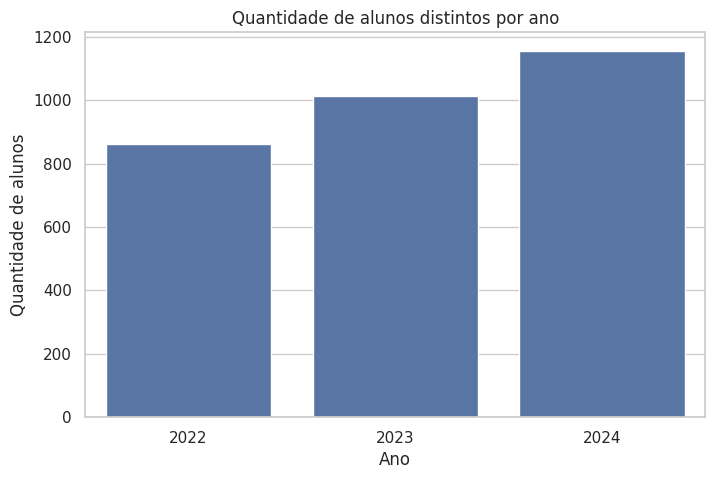

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(data=perfil.reset_index(), x="Ano", y="Alunos_distintos")
plt.title("Quantidade de alunos distintos por ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de alunos")
plt.show()

In [13]:
# distribuição dos alunos por fase

fase_ano = pd.crosstab(df["Ano"], df["Fase"])
display(fase_ano)

fase_pct = pd.crosstab(df["Ano"], df["Fase"], normalize="index") * 100
display(fase_pct.round(2))

Fase,0,1,2,3,4,5,6,7,9,1A,1B,1C,1D,1E,1G,1H,1J,1K,1L,1M,1N,1P,1R,2A,2B,2C,2D,2G,2H,2I,2K,2L,2M,2N,2P,2R,2U,3A,3B,3C,3D,3F,3G,3H,3I,3K,3L,3M,3N,3P,3R,3U,4A,4B,4C,4F,4H,4L,4M,4N,4R,5A,5B,5C,5D,5F,5G,5L,5M,5N,6A,6L,7A,7E,8A,8B,8D,8E,8F,ALFA,FASE 1,FASE 2,FASE 3,FASE 4,FASE 5,FASE 6,FASE 7,FASE 8
Ano,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022,190,192,155,148,76,60,18,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2023,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,231,173,200,132,94,65,33,23,63
2024,0,0,0,0,0,0,0,0,38,14,15,14,10,8,16,12,13,15,15,15,15,9,14,13,11,8,14,14,14,11,16,16,16,13,14,10,15,15,16,15,16,12,15,13,10,16,14,15,12,15,11,16,15,17,12,16,4,15,18,12,6,14,10,13,11,10,6,9,13,14,13,12,12,25,2,13,12,23,14,196,0,0,0,0,0,0,0,0


Fase,0,1,2,3,4,5,6,7,9,1A,1B,1C,1D,1E,1G,1H,1J,1K,1L,1M,1N,1P,1R,2A,2B,2C,2D,2G,2H,2I,2K,2L,2M,2N,2P,2R,2U,3A,3B,3C,3D,3F,3G,3H,3I,3K,3L,3M,3N,3P,3R,3U,4A,4B,4C,4F,4H,4L,4M,4N,4R,5A,5B,5C,5D,5F,5G,5L,5M,5N,6A,6L,7A,7E,8A,8B,8D,8E,8F,ALFA,FASE 1,FASE 2,FASE 3,FASE 4,FASE 5,FASE 6,FASE 7,FASE 8
Ano,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022,22.09,22.33,18.02,17.21,8.84,6.98,2.09,2.44,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2023,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,22.78,17.06,19.72,13.02,9.27,6.41,3.25,2.27,6.21
2024,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.29,1.21,1.30,1.21,0.87,0.69,1.38,1.04,1.12,1.30,1.30,1.30,1.30,0.78,1.21,1.12,0.95,0.69,1.21,1.21,1.21,0.95,1.38,1.38,1.38,1.12,1.21,0.87,1.30,1.30,1.38,1.30,1.38,1.04,1.30,1.12,0.87,1.38,1.21,1.30,1.04,1.30,0.95,1.38,1.30,1.47,1.04,1.38,0.35,1.30,1.56,1.04,0.52,1.21,0.87,1.12,0.95,0.87,0.52,0.78,1.12,1.21,1.12,1.04,1.04,2.16,0.17,1.12,1.04,1.99,1.21,16.96,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


### 2.2 Estatísticas descritivas dos indicadores

In [14]:
estatisticas = df[INDICADORES].describe().T
estatisticas["Mediana"] = df[INDICADORES].median()
estatisticas["Variância"] = df[INDICADORES].var()
estatisticas["Assimetria"] = df[INDICADORES].skew()

display(estatisticas.round(3))

,count,mean,std,min,25%,50%,75%,max,Mediana,Variância,Assimetria
INDE,2845.00,7.27,0.99,3.03,6.67,7.39,7.99,9.53,7.39,0.98,-0.60
IAA,2865.00,7.92,2.63,0.00,7.90,8.75,9.50,10.00,8.75,6.90,-2.30
IEG,2954.00,7.95,2.15,0.00,7.30,8.60,9.40,10.00,8.60,4.63,-2.06
IPS,2859.00,6.29,1.79,2.50,5.02,7.50,7.51,10.00,7.50,3.21,-0.97
IPP,1992.00,7.55,0.94,2.50,7.08,7.50,8.12,10.00,7.50,0.88,-0.77
IDA,2852.00,6.38,1.96,0.00,5.10,6.67,7.83,10.00,6.67,3.83,-0.60
IPV,2852.00,7.54,1.08,2.50,6.98,7.58,8.26,10.01,7.58,1.18,-0.58
IAN,3030.00,7.18,2.54,2.50,5.00,5.00,10.00,10.00,5.00,6.43,0.17


### 2.3 Evolução média dos indicadores — 2022 a 2024

,INDE,IAA,IEG,IPS,IPP,IDA,IPV,IAN
Ano,,,,,,,,
2022,7.04,8.27,7.89,6.90,NaN,6.09,7.25,6.42
2023,7.34,6.90,8.70,5.12,7.56,6.66,8.03,7.24
2024,7.40,8.54,7.37,6.83,7.55,6.35,7.35,7.68


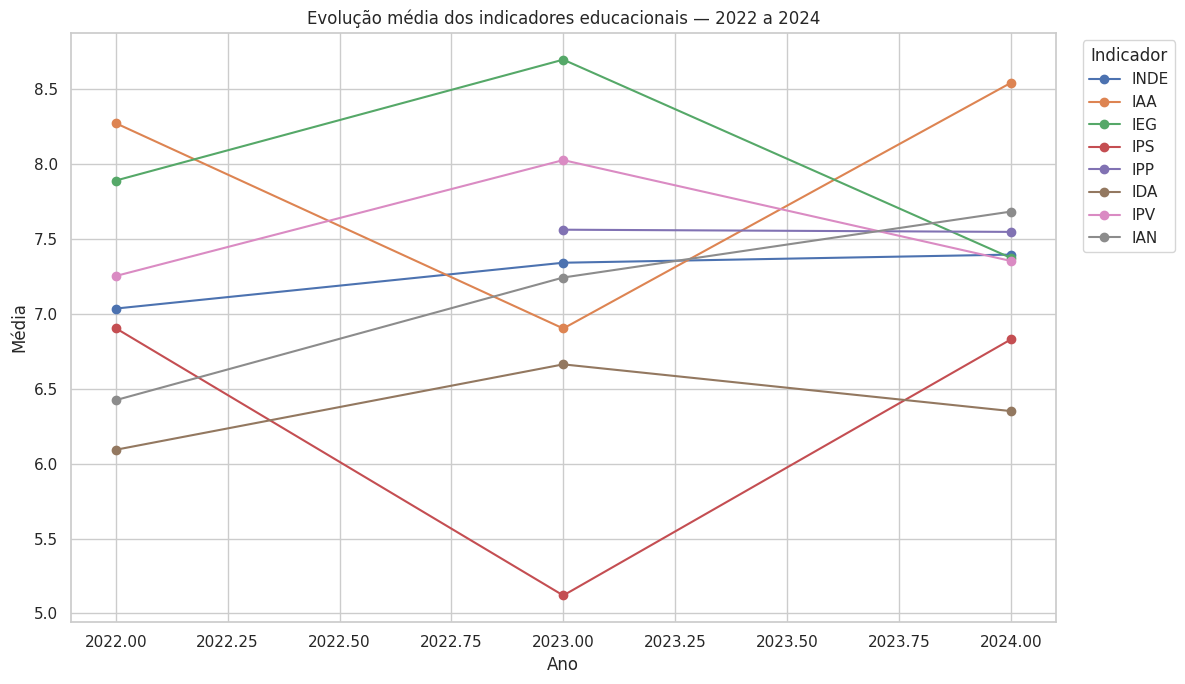

In [15]:
media_ano = df.groupby("Ano")[INDICADORES].mean()
display(media_ano.round(2))

media_ano.plot(marker="o", figsize=(12,7))
plt.title("Evolução média dos indicadores educacionais — 2022 a 2024")
plt.xlabel("Ano")
plt.ylabel("Média")
plt.legend(title="Indicador", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 2.4 IAN — Adequação do nível

,N,Média,Mediana,Desvio_Padrão,Mínimo,Máximo
Ano,,,,,,
2022,860,6.42,5.00,2.39,2.50,10.00
2023,1014,7.24,5.00,2.54,2.50,10.00
2024,1156,7.68,10.00,2.50,2.50,10.00


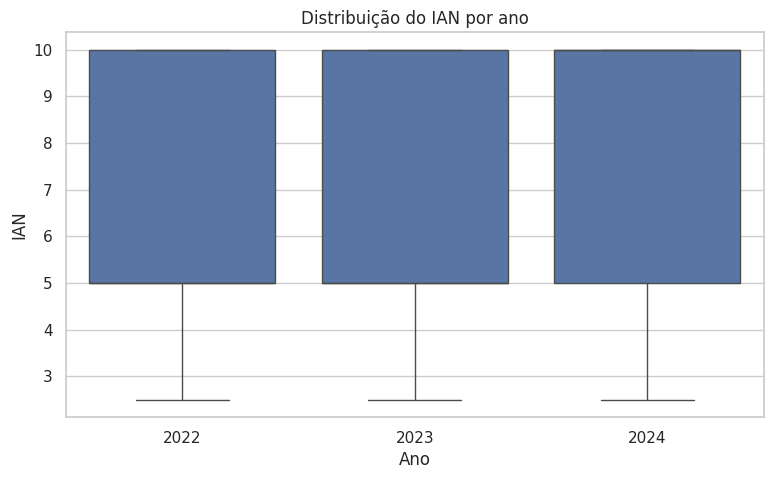

In [16]:
ian_ano = df.groupby("Ano")["IAN"].agg(
    N="count",
    Média="mean",
    Mediana="median",
    Desvio_Padrão="std",
    Mínimo="min",
    Máximo="max"
).round(2)

display(ian_ano)

plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="Ano", y="IAN")
plt.title("Distribuição do IAN por ano")
plt.show()

### 2.5 Defasagem

Valores encontrados na variável Defasagem:


,count
Defasagem,
-5,1
-4,5
-3,39
-2,383
-1,1259
0,1152
1,165
2,24
3,2


Defasagem,-5,-4,-3,-2,-1,0,1,2,3
Ano,,,,,,,,,
2022,0.12,0.47,2.67,18.95,47.67,28.72,1.05,0.35,0.00
2023,0.00,0.10,1.28,12.82,40.24,41.42,3.65,0.49,0.00
2024,0.00,0.00,0.26,7.79,38.15,41.96,10.29,1.38,0.17


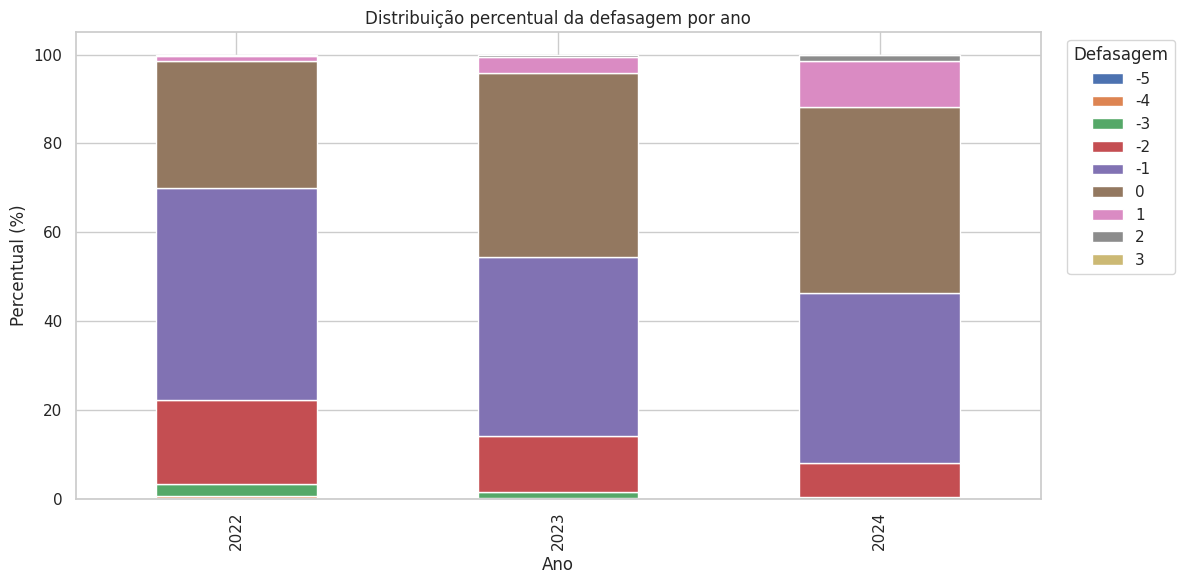

In [17]:
print("Valores encontrados na variável Defasagem:")
display(df["Defasagem"].value_counts(dropna=False).sort_index())

defasagem_pct = pd.crosstab(
    df["Ano"], df["Defasagem"], normalize="index"
) * 100

display(defasagem_pct.round(2))

defasagem_pct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Distribuição percentual da defasagem por ano")
plt.xlabel("Ano")
plt.ylabel("Percentual (%)")
plt.legend(title="Defasagem", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

### 2.6 IDA — Desempenho acadêmico

,N,Média,Mediana,Desvio_Padrão,Mínimo,Máximo
Ano,,,,,,
2022,860,6.09,6.30,2.05,0.00,9.90
2023,937,6.66,6.80,1.60,0.00,10.00
2024,1055,6.35,6.75,2.13,0.00,10.00


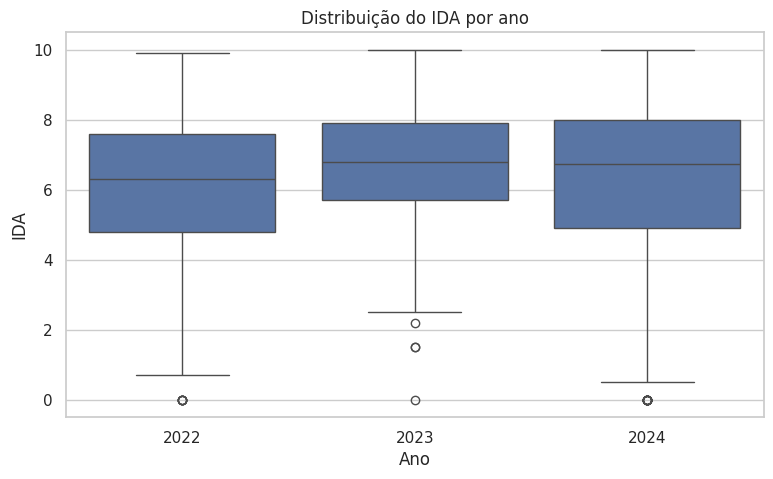

In [18]:
ida_ano = df.groupby("Ano")["IDA"].agg(
    N="count",
    Média="mean",
    Mediana="median",
    Desvio_Padrão="std",
    Mínimo="min",
    Máximo="max"
).round(2)

display(ida_ano)

plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="Ano", y="IDA")
plt.title("Distribuição do IDA por ano")
plt.show()

In [19]:
# Verificar como a variável Fase está registrada em cada ano

for ano in [2022, 2023, 2024]:
    print(f"\n===== FASES EM {ano} =====")

    print(
        sorted(
            df.loc[df["Ano"] == ano, "Fase"]
              .dropna()
              .astype(str)
              .unique()
        )
    )


===== FASES EM 2022 =====
['0', '1', '2', '3', '4', '5', '6', '7']

===== FASES EM 2023 =====
['ALFA', 'FASE 1', 'FASE 2', 'FASE 3', 'FASE 4', 'FASE 5', 'FASE 6', 'FASE 7', 'FASE 8']

===== FASES EM 2024 =====
['1A', '1B', '1C', '1D', '1E', '1G', '1H', '1J', '1K', '1L', '1M', '1N', '1P', '1R', '2A', '2B', '2C', '2D', '2G', '2H', '2I', '2K', '2L', '2M', '2N', '2P', '2R', '2U', '3A', '3B', '3C', '3D', '3F', '3G', '3H', '3I', '3K', '3L', '3M', '3N', '3P', '3R', '3U', '4A', '4B', '4C', '4F', '4H', '4L', '4M', '4N', '4R', '5A', '5B', '5C', '5D', '5F', '5G', '5L', '5M', '5N', '6A', '6L', '7A', '7E', '8A', '8B', '8D', '8E', '8F', '9', 'ALFA']


### 2.7 Tratamento de FASE e TURMA

A documentação da Passos Mágicos distingue Fase (nível de aprendizado)
de Turma (identificação das turmas existentes dentro de cada fase).

Como a nomenclatura varia entre os anos, foi criada uma variável
padronizada para permitir comparações temporais.

A categoria Fase 0 foi tratada como ALFA para fins de comparação,
conforme a estrutura metodológica disponível. A Fase 8 será analisada
separadamente por possuir particularidades metodológicas, e a Fase 9
não será interpretada comparativamente por não possuir definição
na documentação disponibilizada.

In [20]:
# Criação FASE COMPARÁVEL

import re
import numpy as np

def criar_fase_comparavel(valor):

    if pd.isna(valor):
        return np.nan

    texto = str(valor).upper().strip()

    if texto == "ALFA":
        return "ALFA"

    numero = re.search(r'\d+', texto)

    if numero:
        n = int(numero.group())

        if n == 0:
            return "ALFA"

        return f"FASE {n}"

    return np.nan


df["Fase_Comparavel"] = df["Fase"].apply(criar_fase_comparavel)

display(
    pd.crosstab(
        df["Ano"],
        df["Fase_Comparavel"]
    )
)

Fase_Comparavel,ALFA,FASE 1,FASE 2,FASE 3,FASE 4,FASE 5,FASE 6,FASE 7,FASE 8,FASE 9
Ano,,,,,,,,,,
2022,190,192,155,148,76,60,18,21,0,0
2023,231,173,200,132,94,65,33,23,63,0
2024,196,185,185,211,115,100,25,37,64,38


In [21]:
# Tabela definitiva por FASE

analise_fase_final = (
    df.groupby(
        ["Ano", "Fase_Comparavel"],
        observed=True
    )
    .agg(
        Alunos=("RA", "nunique"),
        IDA_medio=("IDA", "mean"),
        IEG_medio=("IEG", "mean"),
        INDE_medio=("INDE", "mean"),
        IAN_medio=("IAN", "mean"),
        IPS_medio=("IPS", "mean"),
        IPV_medio=("IPV", "mean")
    )
    .reset_index()
)

display(analise_fase_final.round(2))

,Ano,Fase_Comparavel,Alunos,IDA_medio,IEG_medio,INDE_medio,IAN_medio,IPS_medio,IPV_medio
0,2022,ALFA,190,7.14,8.09,7.37,6.80,7.01,7.56
1,2022,FASE 1,192,6.46,8.52,7.20,5.74,7.08,7.36
2,2022,FASE 2,155,5.41,8.17,6.96,6.40,6.82,7.34
3,2022,FASE 3,148,5.14,7.07,6.60,6.99,6.72,6.55
4,2022,FASE 4,76,6.05,7.66,7.01,6.48,6.61,7.21
5,2022,FASE 5,60,5.87,7.34,6.88,6.25,6.86,7.26
6,2022,FASE 6,18,6.69,7.03,7.20,5.83,7.96,8.22
7,2022,FASE 7,21,5.25,7.24,6.64,6.19,6.52,7.18
8,2023,ALFA,231,7.42,8.94,7.68,7.46,5.78,8.32
9,2023,FASE 1,173,6.81,8.74,7.45,6.17,6.12,8.10


In [22]:
# Separeação das FASES comparáveis

ordem_fases = [
    "ALFA",
    "FASE 1",
    "FASE 2",
    "FASE 3",
    "FASE 4",
    "FASE 5",
    "FASE 6",
    "FASE 7"
]

fase_comp_final = analise_fase_final[
    analise_fase_final["Fase_Comparavel"].isin(ordem_fases)
].copy()

fase_comp_final["Fase_Comparavel"] = pd.Categorical(
    fase_comp_final["Fase_Comparavel"],
    categories=ordem_fases,
    ordered=True
)

fase_comp_final = fase_comp_final.sort_values(
    ["Ano", "Fase_Comparavel"]
)

display(fase_comp_final.round(2))

,Ano,Fase_Comparavel,Alunos,IDA_medio,IEG_medio,INDE_medio,IAN_medio,IPS_medio,IPV_medio
0,2022,ALFA,190,7.14,8.09,7.37,6.80,7.01,7.56
1,2022,FASE 1,192,6.46,8.52,7.20,5.74,7.08,7.36
2,2022,FASE 2,155,5.41,8.17,6.96,6.40,6.82,7.34
3,2022,FASE 3,148,5.14,7.07,6.60,6.99,6.72,6.55
4,2022,FASE 4,76,6.05,7.66,7.01,6.48,6.61,7.21
5,2022,FASE 5,60,5.87,7.34,6.88,6.25,6.86,7.26
6,2022,FASE 6,18,6.69,7.03,7.20,5.83,7.96,8.22
7,2022,FASE 7,21,5.25,7.24,6.64,6.19,6.52,7.18
8,2023,ALFA,231,7.42,8.94,7.68,7.46,5.78,8.32
9,2023,FASE 1,173,6.81,8.74,7.45,6.17,6.12,8.10


### 2.8 Desempenho acadêmico - IDA por Fase

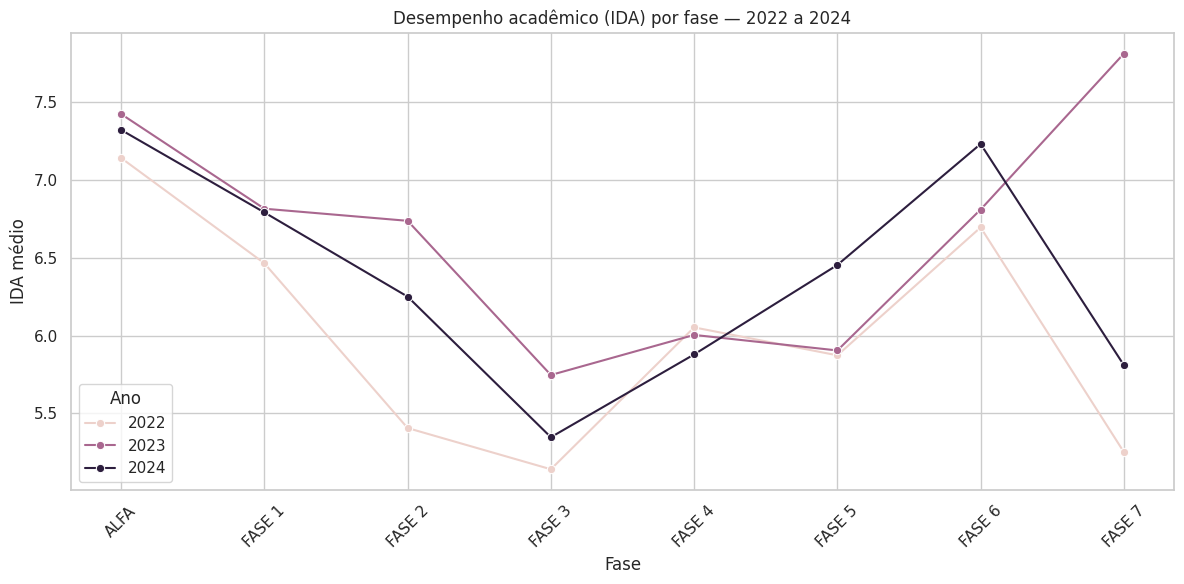

In [23]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=fase_comp_final,
    x="Fase_Comparavel",
    y="IDA_medio",
    hue="Ano",
    marker="o"
)

plt.title("Desempenho acadêmico (IDA) por fase — 2022 a 2024")
plt.xlabel("Fase")
plt.ylabel("IDA médio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.9 Engajamento - IEG por Fase

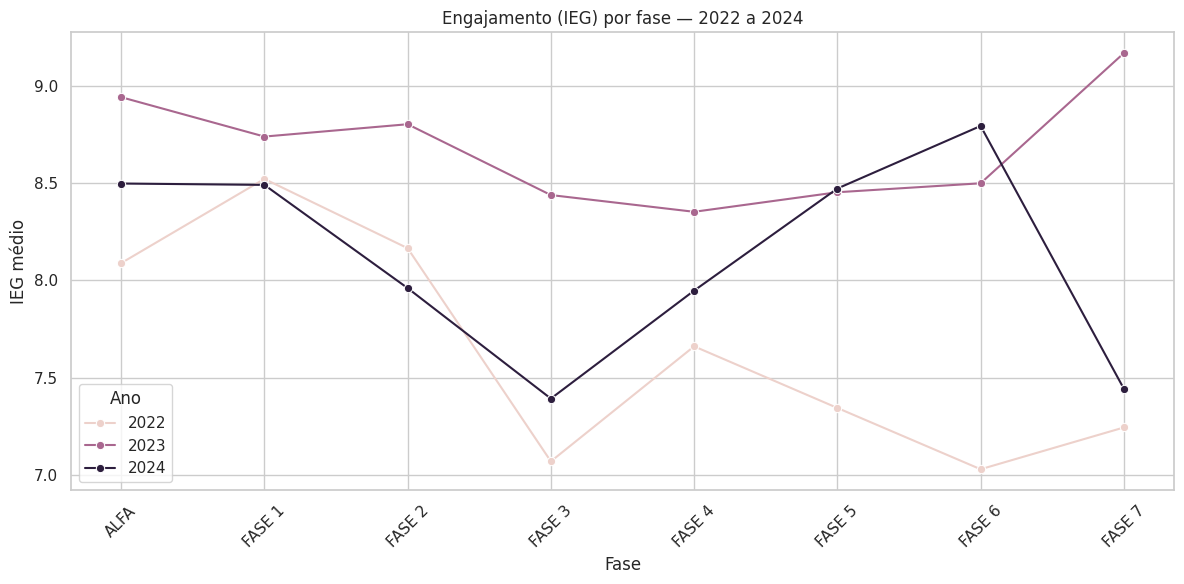

In [24]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=fase_comp_final,
    x="Fase_Comparavel",
    y="IEG_medio",
    hue="Ano",
    marker="o"
)

plt.title("Engajamento (IEG) por fase — 2022 a 2024")
plt.xlabel("Fase")
plt.ylabel("IEG médio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.10 INDE por Fase

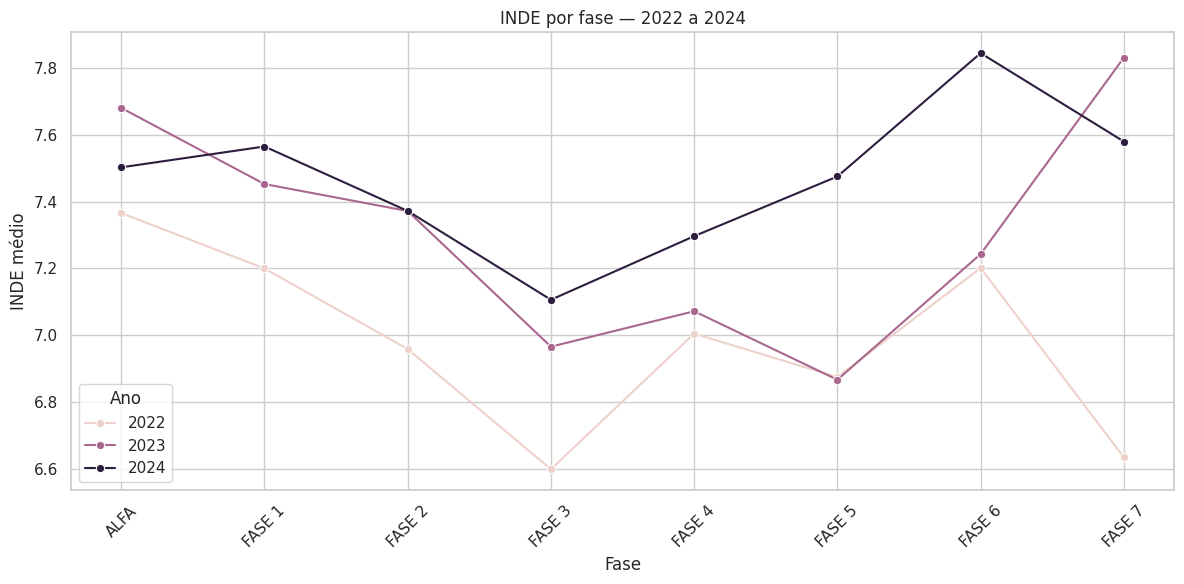

In [25]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=fase_comp_final,
    x="Fase_Comparavel",
    y="INDE_medio",
    hue="Ano",
    marker="o"
)

plt.title("INDE por fase — 2022 a 2024")
plt.xlabel("Fase")
plt.ylabel("INDE médio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.11 Análise Fase 8

In [26]:
fase8 = analise_fase_final[
    analise_fase_final["Fase_Comparavel"] == "FASE 8"
]

display(fase8.round(2))

,Ano,Fase_Comparavel,Alunos,IDA_medio,IEG_medio,INDE_medio,IAN_medio,IPS_medio,IPV_medio
16,2023,FASE 8,63,NaN,NaN,NaN,10.00,NaN,NaN
25,2024,FASE 8,64,8.00,0.00,NaN,10.00,NaN,NaN


### 2.12 Análise Fase 9

In [27]:
fase9 = analise_fase_final[
    analise_fase_final["Fase_Comparavel"] == "FASE 9"
]

display(fase9.round(2))

,Ano,Fase_Comparavel,Alunos,IDA_medio,IEG_medio,INDE_medio,IAN_medio,IPS_medio,IPV_medio
26,2024,FASE 9,38,NaN,0.00,NaN,10.00,NaN,NaN


### 2.13 Matriz de correlação dos indicadores

,INDE,IAA,IEG,IPS,IPP,IDA,IPV,IAN
INDE,1.00,0.40,0.75,0.20,0.54,0.79,0.72,0.41
IAA,0.40,1.00,0.13,0.16,0.05,0.12,0.06,0.03
IEG,0.75,0.13,1.00,-0.05,0.33,0.54,0.56,-0.06
IPS,0.20,0.16,-0.05,1.00,0.06,0.02,-0.05,0.00
IPP,0.54,0.05,0.33,0.06,1.00,0.37,0.61,0.12
IDA,0.79,0.12,0.54,0.02,0.37,1.00,0.56,0.12
IPV,0.72,0.06,0.56,-0.05,0.61,0.56,1.00,0.15
IAN,0.41,0.03,-0.06,0.00,0.12,0.12,0.15,1.00


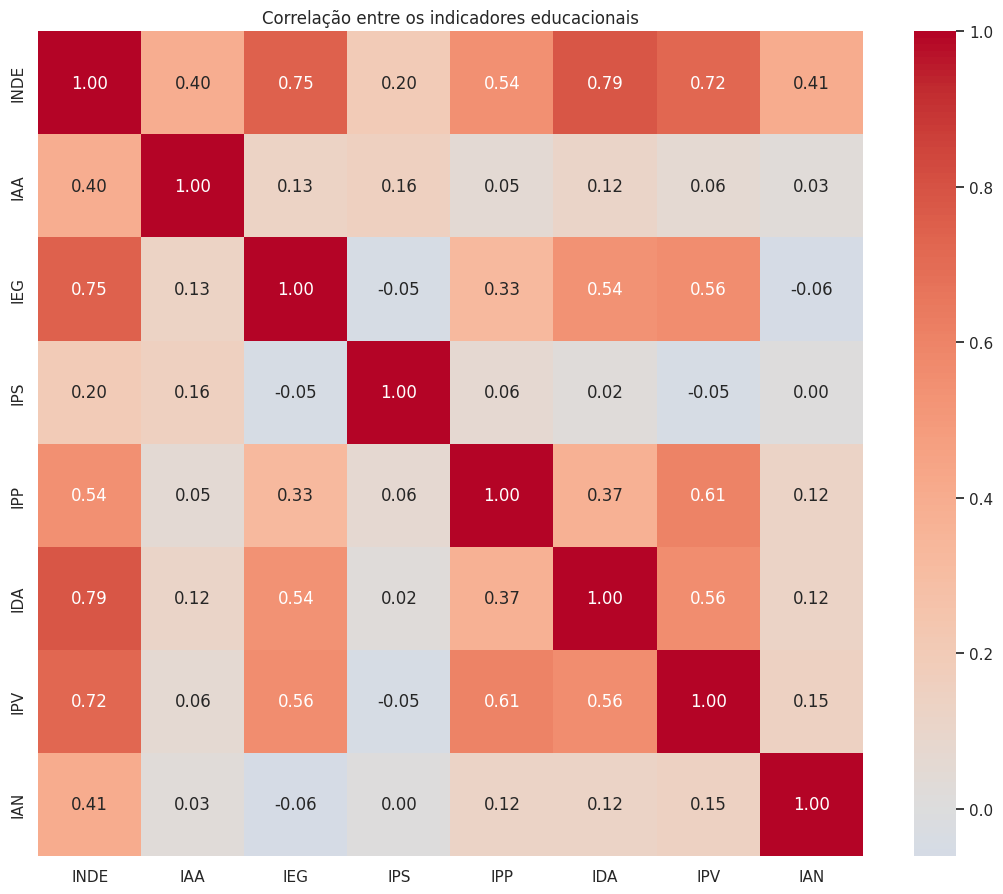

In [28]:
correlacao = df[INDICADORES].corr()
display(correlacao.round(2))

plt.figure(figsize=(11,9))
sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Correlação entre os indicadores educacionais")
plt.tight_layout()
plt.show()

### 2.14 IEG × IDA

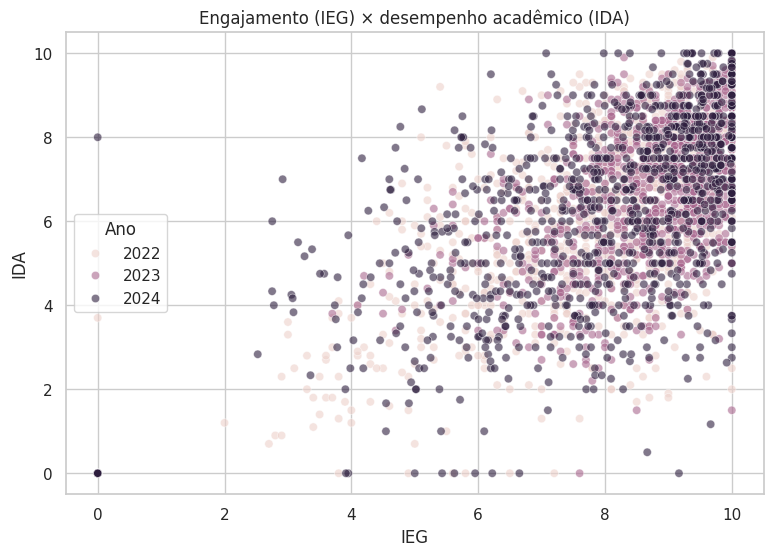

,IEG,IDA
IEG,1.00,0.54
IDA,0.54,1.00


In [29]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="IEG", y="IDA", hue="Ano", alpha=0.6)
plt.title("Engajamento (IEG) × desempenho acadêmico (IDA)")
plt.show()

display(df[["IEG", "IDA"]].corr().round(3))

### 2.15 IEG × IPV

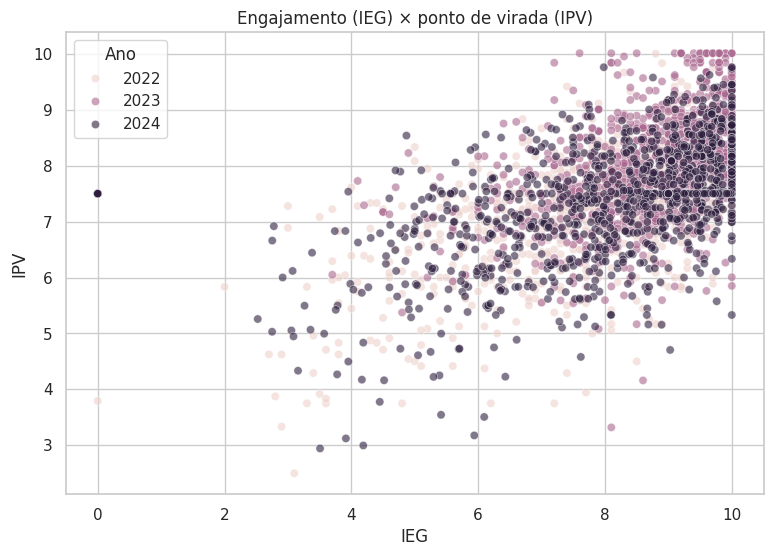

,IEG,IPV
IEG,1.00,0.56
IPV,0.56,1.00


In [30]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="IEG", y="IPV", hue="Ano", alpha=0.6)
plt.title("Engajamento (IEG) × ponto de virada (IPV)")
plt.show()

display(df[["IEG", "IPV"]].corr().round(3))

### 2.16 Indicadores associados ao IPV

In [31]:
variaveis_ipv = [
    "IPV",
    "IDA",
    "IEG",
    "IAA",
    "IPS",
    "IPP",
    "IAN"
]

cor_ipv = (
    df[variaveis_ipv]
    .corr()["IPV"]
    .drop("IPV")
    .sort_values(ascending=False)
)

display(cor_ipv.round(3))

,IPV
IPP,0.61
IEG,0.56
IDA,0.56
IAN,0.15
IAA,0.06
IPS,-0.05


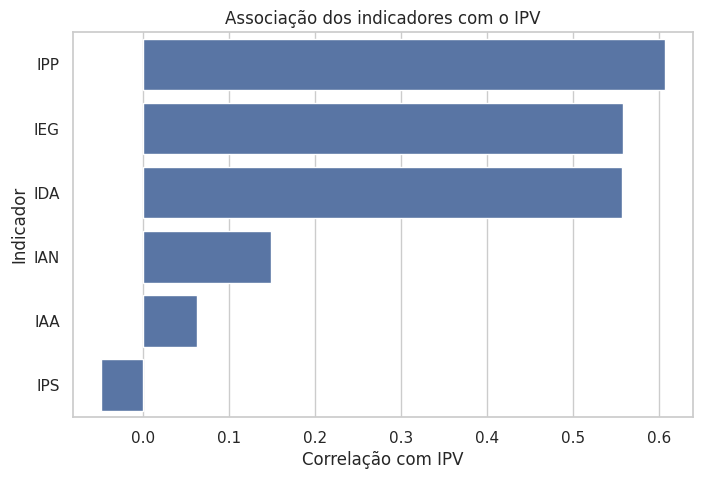

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=cor_ipv.values,
    y=cor_ipv.index
)

plt.title("Associação dos indicadores com o IPV")
plt.xlabel("Correlação com IPV")
plt.ylabel("Indicador")

plt.show()

### 2.17 Análise temporal do IPV

In [33]:
ipv_ano = (
    df.groupby("Ano")["IPV"]
    .agg(["count", "mean", "median", "std"])
)

display(ipv_ano.round(2))

,count,mean,median,std
Ano,,,,
2022,860,7.25,7.33,1.09
2023,938,8.03,8.04,0.95
2024,1054,7.35,7.50,1.05


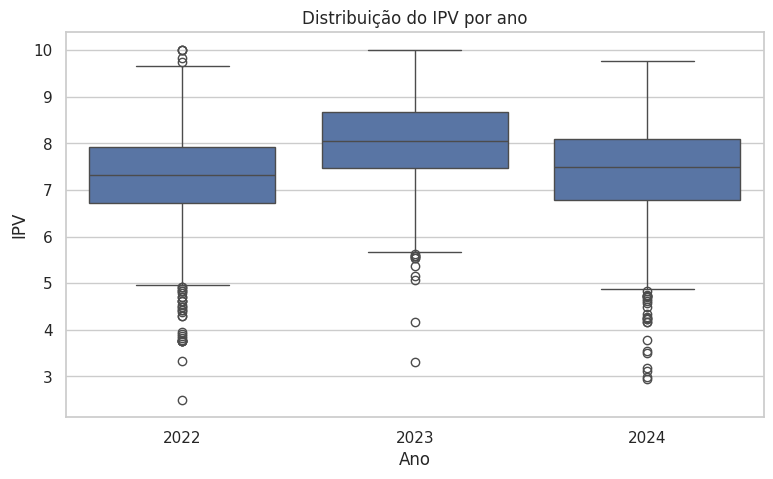

In [34]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="Ano",
    y="IPV"
)

plt.title("Distribuição do IPV por ano")
plt.xlabel("Ano")
plt.ylabel("IPV")

plt.show()

In [35]:
painel_ipv = (
    df[
        [
            "RA",
            "Ano",
            "IDA",
            "IEG",
            "IAA",
            "IPS",
            "IPP",
            "IAN",
            "IPV"
        ]
    ]
    .sort_values(["RA", "Ano"])
    .copy()
)

painel_ipv["IPV_proximo"] = (
    painel_ipv.groupby("RA")["IPV"]
    .shift(-1)
)

painel_ipv["Ano_proximo"] = (
    painel_ipv.groupby("RA")["Ano"]
    .shift(-1)
)

painel_ipv["Delta_IPV"] = (
    painel_ipv["IPV_proximo"] -
    painel_ipv["IPV"]
)

painel_ipv = painel_ipv[
    painel_ipv["Ano_proximo"] ==
    painel_ipv["Ano"] + 1
].copy()

In [36]:
preditores_ipv = [
    "IDA",
    "IEG",
    "IAA",
    "IPS",
    "IPP",
    "IAN"
]

corr_delta_ipv = (
    painel_ipv[preditores_ipv + ["Delta_IPV"]]
    .corr()["Delta_IPV"]
    .drop("Delta_IPV")
    .sort_values(ascending=False)
)

display(corr_delta_ipv.round(3))

,Delta_IPV
IPS,0.28
IAA,0.16
IAN,0.05
IPP,-0.00
IDA,-0.14
IEG,-0.21


### 2.18 Verificação Ponto de Virada

In [37]:
for ano, base in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:
    print(f"\n===== {ano} =====")

    colunas_pv = [
        c for c in base.columns
        if "virada" in str(c).lower()
    ]

    print(colunas_pv)


===== 2022 =====
[]

===== 2023 =====
[]

===== 2024 =====
[]


### 2.19 IAA × IDA

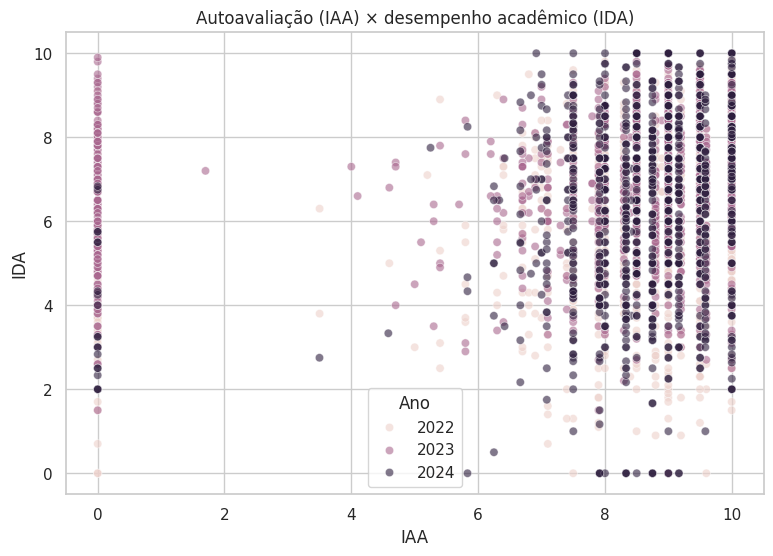

,IAA,IDA
IAA,1.00,0.12
IDA,0.12,1.00


In [38]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="IAA", y="IDA", hue="Ano", alpha=0.6)
plt.title("Autoavaliação (IAA) × desempenho acadêmico (IDA)")
plt.show()

display(df[["IAA", "IDA"]].corr().round(3))

### 2.20 Relação entre Autoavaliação (IAA) e Engajamento (IEG)

Para complementar a análise da autoavaliação, verificamos sua
associação com o Indicador de Engajamento (IEG), considerando o conjunto dos dados e cada ano separadamente.

In [39]:
# Correlação geral entre IAA e IEG

dados_iaa_ieg = df[["IAA", "IEG"]].dropna()

corr_iaa_ieg = dados_iaa_ieg["IAA"].corr(dados_iaa_ieg["IEG"])

print(f"Correlação geral IAA × IEG: {corr_iaa_ieg:.2f}")
print(f"Número de observações: {len(dados_iaa_ieg)}")

Correlação geral IAA × IEG: 0.13
Número de observações: 2852


In [40]:
# Correlação IAA × IEG por ano

for ano in sorted(df["Ano"].dropna().unique()):

    dados_ano = df.loc[
        df["Ano"] == ano,
        ["IAA", "IEG"]
    ].dropna()

    correlacao = dados_ano["IAA"].corr(dados_ano["IEG"])

    print(
        f"{ano}: "
        f"N = {len(dados_ano)} | "
        f"Correlação IAA × IEG = {correlacao:.2f}"
    )

2022: N = 860 | Correlação IAA × IEG = 0.32
2023: N = 938 | Correlação IAA × IEG = 0.17
2024: N = 1054 | Correlação IAA × IEG = 0.23


### 2.21 IPS × IDA

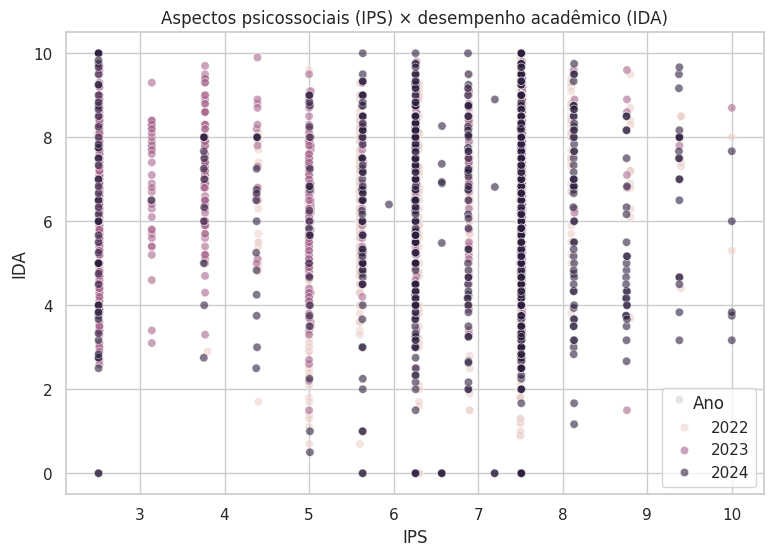

,IPS,IDA
IPS,1.00,0.02
IDA,0.02,1.00


In [41]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="IPS", y="IDA", hue="Ano", alpha=0.6)
plt.title("Aspectos psicossociais (IPS) × desempenho acadêmico (IDA)")
plt.show()

display(df[["IPS", "IDA"]].corr().round(3))

### 2.22 Análise temporal do IPS

In [42]:
# Verificar se o IPS de um ano está associado à variação posterior do desempenho acadêmico (IDA) e do engajamento (IEG).
# Criar painel por aluno e ano

painel = (
    df[["RA", "Ano", "IPS", "IDA", "IEG"]]
    .sort_values(["RA", "Ano"])
    .copy()
)

# Valores do ano seguinte para o mesmo aluno
painel["IDA_proximo"] = painel.groupby("RA")["IDA"].shift(-1)
painel["IEG_proximo"] = painel.groupby("RA")["IEG"].shift(-1)
painel["Ano_proximo"] = painel.groupby("RA")["Ano"].shift(-1)

# Garantir que estamos realmente comparando anos consecutivos
painel["Ano_consecutivo"] = (
    painel["Ano_proximo"] == painel["Ano"] + 1
)

painel["Delta_IDA"] = painel["IDA_proximo"] - painel["IDA"]
painel["Delta_IEG"] = painel["IEG_proximo"] - painel["IEG"]

painel_temporal = painel[
    painel["Ano_consecutivo"]
].copy()

display(painel_temporal.head())

,RA,Ano,IPS,IDA,IEG,IDA_proximo,IEG_proximo,Ano_proximo,Ano_consecutivo,Delta_IDA,Delta_IEG
0,RA-1,2022,5.60,4.00,4.10,NaN,NaN,2023.00,True,NaN,NaN
1855,RA-1,2023,NaN,NaN,NaN,NaN,0.00,2024.00,True,NaN,NaN
1072,RA-1000,2023,3.77,7.00,9.40,7.75,9.55,2024.00,True,0.75,0.15
1074,RA-1001,2023,7.52,7.80,9.10,7.75,9.35,2024.00,True,-0.05,0.25
1075,RA-1002,2023,7.52,7.00,9.70,9.25,7.83,2024.00,True,2.25,-1.87


* Delta_IDA > 0 → desempenho aumentou
* Delta_IDA < 0 → desempenho caiu
* Delta_IEG > 0 → engajamento aumentou
* Delta_IEG < 0 → engajamento caiu

### 2.23 IPS anterior × mudança futura do IDA

In [43]:
corr_ips_delta_ida = (
    painel_temporal[["IPS", "Delta_IDA"]]
    .corr()
)

display(corr_ips_delta_ida.round(3))

,IPS,Delta_IDA
IPS,1.00,0.12
Delta_IDA,0.12,1.00


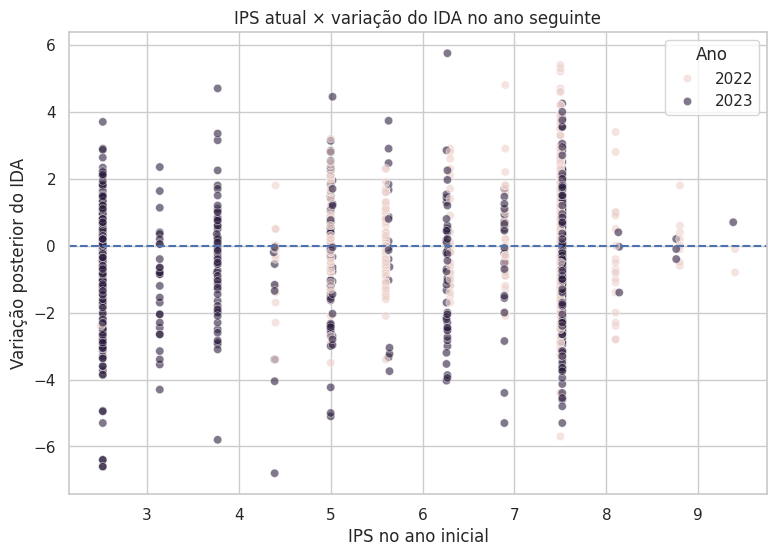

In [44]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=painel_temporal,
    x="IPS",
    y="Delta_IDA",
    hue="Ano",
    alpha=0.6
)

plt.axhline(0, linestyle="--")

plt.title("IPS atual × variação do IDA no ano seguinte")
plt.xlabel("IPS no ano inicial")
plt.ylabel("Variação posterior do IDA")

plt.show()

### 2.24 IPS anterior × mudança futura do IEG

In [45]:
corr_ips_delta_ieg = (
    painel_temporal[["IPS", "Delta_IEG"]]
    .corr()
)

display(corr_ips_delta_ieg.round(3))

,IPS,Delta_IEG
IPS,1.00,0.16
Delta_IEG,0.16,1.00


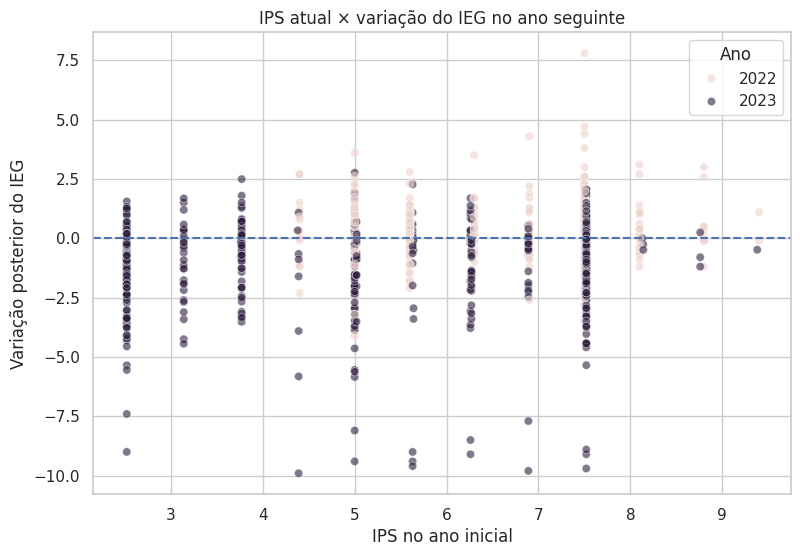

In [46]:
# IPS atual × variação do IEG no ano seguinte

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=painel_temporal,
    x="IPS",
    y="Delta_IEG",
    hue="Ano",
    alpha=0.6
)

plt.axhline(0, linestyle="--")

plt.title("IPS atual × variação do IEG no ano seguinte")
plt.xlabel("IPS no ano inicial")
plt.ylabel("Variação posterior do IEG")

plt.show()

In [47]:
painel_temporal["Queda_IDA"] = (
    painel_temporal["Delta_IDA"] < 0
)

painel_temporal["Queda_IEG"] = (
    painel_temporal["Delta_IEG"] < 0
)

In [48]:
display(
    painel_temporal.groupby("Queda_IDA")["IPS"]
    .agg(["count", "mean", "median"])
    .round(2)
)

,count,mean,median
Queda_IDA,,,
False,630,6.06,6.90
True,673,5.87,6.30


In [49]:
display(
    painel_temporal.groupby("Queda_IEG")["IPS"]
    .agg(["count", "mean", "median"])
    .round(2)
)

,count,mean,median
Queda_IEG,,,
False,629,6.24,7.50
True,674,5.70,6.27


### 2.25 IPP × IAN (somente onde IPP existe)

,N
Ano,
2023,938
2024,1054


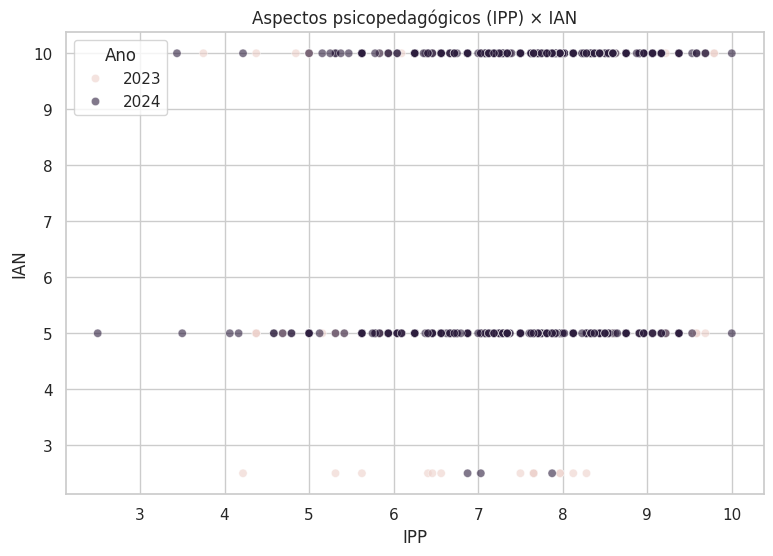

,IPP,IAN
IPP,1.00,0.12
IAN,0.12,1.00


In [50]:
# aspectos psicopedagógicos IPP x IAN

ipp_ian = df[["Ano", "IPP", "IAN"]].dropna()

display(ipp_ian.groupby("Ano").size().rename("N"))

plt.figure(figsize=(9,6))
sns.scatterplot(data=ipp_ian, x="IPP", y="IAN", hue="Ano", alpha=0.6)
plt.title("Aspectos psicopedagógicos (IPP) × IAN")
plt.show()

display(ipp_ian[["IPP", "IAN"]].corr().round(3))

### 2.26 Indicadores relacionados ao INDE

,INDE
INDE,1.00
IDA,0.79
IEG,0.74
IPV,0.72
IPP,0.54
IAN,0.41
IAA,0.40
IPS,0.20


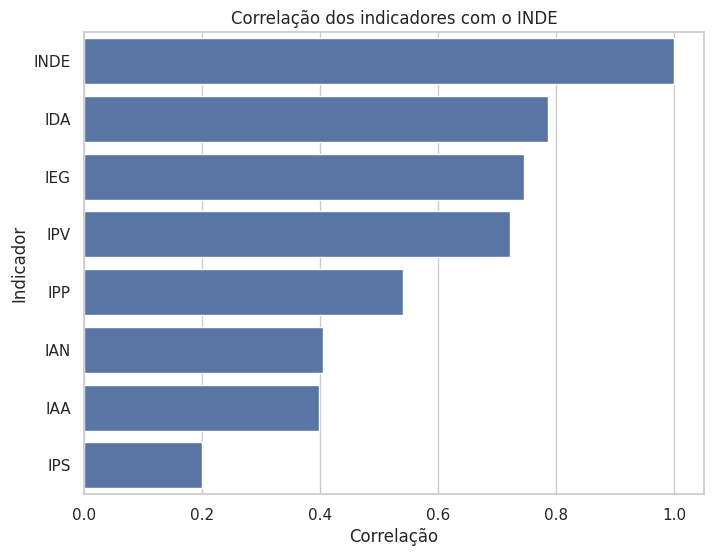

In [51]:
cor_inde = (
    df[["INDE", "IAA", "IEG", "IPS", "IPP", "IDA", "IPV", "IAN"]]
    .corr()["INDE"]
    .sort_values(ascending=False)
)

display(cor_inde.round(3))

plt.figure(figsize=(8,6))
sns.barplot(x=cor_inde.values, y=cor_inde.index)
plt.title("Correlação dos indicadores com o INDE")
plt.xlabel("Correlação")
plt.ylabel("Indicador")
plt.show()

**Nota metodológica sobre as correlações com o INDE

As associações entre INDE e IDA, IEG, IPV, IAN, IAA, IPS e IPP
devem ser interpretadas com cautela, pois esses indicadores fazem
parte da própria construção do INDE.

Portanto, correlações elevadas entre esses indicadores e o INDE
não devem ser interpretadas como evidência de causalidade ou como
identificação independente dos fatores que determinam o INDE.

### 2.27 Combinações de IDA, IEG, IPS e IPP associadas ao INDE

Para investigar quais combinações dos indicadores estão associadas aos
maiores valores de INDE, os estudantes foram classificados em grupos
"Alto" e "Baixo" para IDA, IEG, IPS e IPP.

Foi utilizada a mediana de cada indicador como ponto de corte, reduzindo
a influência de valores extremos e permitindo comparar combinações entre
as diferentes dimensões. A análise é descritiva e não deve ser interpretada como evidência de
causalidade.

In [52]:
# Base válida para análise das combinações

indicadores_combo = ["IDA", "IEG", "IPS", "IPP", "INDE"]

df_combo = df.dropna(
    subset=indicadores_combo
).copy()

print("Total de registros utilizados:", len(df_combo))

print("\nRegistros por ano:")
print(df_combo["Ano"].value_counts().sort_index())

Total de registros utilizados: 1985

Registros por ano:
Ano
2023     931
2024    1054
Name: count, dtype: int64


In [53]:
# Classificação Alto/Baixo pela mediana de cada indicador em cada ano

for indicador in ["IDA", "IEG", "IPS", "IPP"]:

    mediana_ano = df_combo.groupby("Ano")[indicador].transform("median")

    df_combo[f"{indicador}_nivel"] = np.where(
        df_combo[indicador] >= mediana_ano,
        "Alto",
        "Baixo"
    )

In [54]:
medianas_combo = (
    df_combo
    .groupby("Ano")[["IDA", "IEG", "IPS", "IPP"]]
    .median()
    .round(2)
)

display(medianas_combo)

,IDA,IEG,IPS,IPP
Ano,,,,
2023,6.80,9.00,5.00,7.66
2024,6.75,8.59,7.51,7.50


In [55]:
df_combo["Combinacao"] = (
    "IDA " + df_combo["IDA_nivel"] +
    " | IEG " + df_combo["IEG_nivel"] +
    " | IPS " + df_combo["IPS_nivel"] +
    " | IPP " + df_combo["IPP_nivel"]
)

In [56]:
resultado_combo = (
    df_combo
    .groupby("Combinacao")
    .agg(
        INDE_medio=("INDE", "mean"),
        INDE_mediana=("INDE", "median"),
        Alunos=("RA", "nunique")
    )
    .reset_index()
    .sort_values("INDE_medio", ascending=False)
)

display(resultado_combo.round(2))

,Combinacao,INDE_medio,INDE_mediana,Alunos
0,IDA Alto | IEG Alto | IPS Alto | IPP Alto,8.33,8.33,268
1,IDA Alto | IEG Alto | IPS Alto | IPP Baixo,8.16,8.19,103
2,IDA Alto | IEG Alto | IPS Baixo | IPP Alto,8.16,8.18,186
4,IDA Alto | IEG Baixo | IPS Alto | IPP Alto,7.78,7.86,125
8,IDA Baixo | IEG Alto | IPS Alto | IPP Alto,7.72,7.70,109
3,IDA Alto | IEG Alto | IPS Baixo | IPP Baixo,7.63,7.70,57
5,IDA Alto | IEG Baixo | IPS Alto | IPP Baixo,7.44,7.43,69
6,IDA Alto | IEG Baixo | IPS Baixo | IPP Alto,7.44,7.42,56
10,IDA Baixo | IEG Alto | IPS Baixo | IPP Alto,7.36,7.44,81
9,IDA Baixo | IEG Alto | IPS Alto | IPP Baixo,7.28,7.37,75


In [57]:
# Combinações com pelo menos 30 estudantes

resultado_combo_robusto = resultado_combo[
    resultado_combo["Alunos"] >= 30
].copy()

display(resultado_combo_robusto.round(2))

,Combinacao,INDE_medio,INDE_mediana,Alunos
0,IDA Alto | IEG Alto | IPS Alto | IPP Alto,8.33,8.33,268
1,IDA Alto | IEG Alto | IPS Alto | IPP Baixo,8.16,8.19,103
2,IDA Alto | IEG Alto | IPS Baixo | IPP Alto,8.16,8.18,186
4,IDA Alto | IEG Baixo | IPS Alto | IPP Alto,7.78,7.86,125
8,IDA Baixo | IEG Alto | IPS Alto | IPP Alto,7.72,7.70,109
3,IDA Alto | IEG Alto | IPS Baixo | IPP Baixo,7.63,7.70,57
5,IDA Alto | IEG Baixo | IPS Alto | IPP Baixo,7.44,7.43,69
6,IDA Alto | IEG Baixo | IPS Baixo | IPP Alto,7.44,7.42,56
10,IDA Baixo | IEG Alto | IPS Baixo | IPP Alto,7.36,7.44,81
9,IDA Baixo | IEG Alto | IPS Alto | IPP Baixo,7.28,7.37,75


In [58]:
resultado_combo_ano = (
    df_combo
    .groupby(["Ano", "Combinacao"])
    .agg(
        INDE_medio=("INDE", "mean"),
        Alunos=("RA", "nunique")
    )
    .reset_index()
    .sort_values(
        ["Ano", "INDE_medio"],
        ascending=[True, False]
    )
)

display(resultado_combo_ano.round(2))

,Ano,Combinacao,INDE_medio,Alunos
1,2023,IDA Alto | IEG Alto | IPS Alto | IPP Baixo,8.25,79
0,2023,IDA Alto | IEG Alto | IPS Alto | IPP Alto,8.21,107
2,2023,IDA Alto | IEG Alto | IPS Baixo | IPP Alto,7.92,87
4,2023,IDA Alto | IEG Baixo | IPS Alto | IPP Alto,7.72,59
8,2023,IDA Baixo | IEG Alto | IPS Alto | IPP Alto,7.70,42
3,2023,IDA Alto | IEG Alto | IPS Baixo | IPP Baixo,7.63,37
5,2023,IDA Alto | IEG Baixo | IPS Alto | IPP Baixo,7.50,44
6,2023,IDA Alto | IEG Baixo | IPS Baixo | IPP Alto,7.43,26
10,2023,IDA Baixo | IEG Alto | IPS Baixo | IPP Alto,7.30,48
9,2023,IDA Baixo | IEG Alto | IPS Alto | IPP Baixo,7.27,51


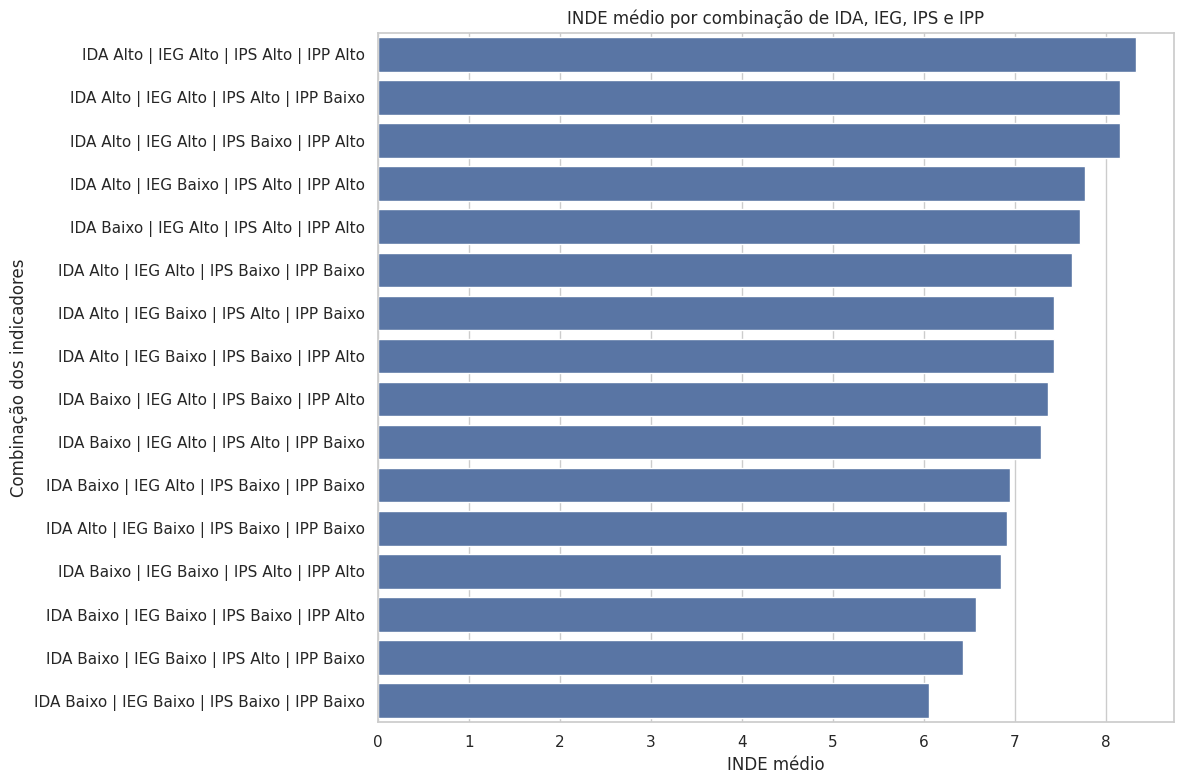

In [59]:
# Gráfico das combinações de indicadores e INDE médio

plt.figure(figsize=(12, 8))

sns.barplot(
    data=resultado_combo,
    y="Combinacao",
    x="INDE_medio"
)

plt.title("INDE médio por combinação de IDA, IEG, IPS e IPP")
plt.xlabel("INDE médio")
plt.ylabel("Combinação dos indicadores")
plt.tight_layout()
plt.show()

### 2.28 Análise longitudinal (foram utilizados os mesmos alunos ao longo do tempo).

In [60]:
presenca = df.groupby("RA")["Ano"].nunique()

print("Alunos presentes em pelo menos 2 anos:", (presenca >= 2).sum())
print("Alunos presentes nos 3 anos:", (presenca == 3).sum())

alunos_3_anos = presenca[presenca == 3].index
df_long = df[df["RA"].isin(alunos_3_anos)].copy()

print("Registros da coorte longitudinal:", len(df_long))

Alunos presentes em pelo menos 2 anos: 901
Alunos presentes nos 3 anos: 468
Registros da coorte longitudinal: 1404


### 2.29 Evolução individual do INDE — 2022 a 2024

In [61]:
inde_long = df_long.pivot_table(
    index="RA",
    columns="Ano",
    values="INDE"
)

display(inde_long.head())

if 2022 in inde_long.columns and 2024 in inde_long.columns:
    inde_long["Variação_22_24"] = inde_long[2024] - inde_long[2022]

    display(inde_long["Variação_22_24"].describe().round(2))

    total_validos = inde_long["Variação_22_24"].notna().sum()
    melhoraram = (inde_long["Variação_22_24"] > 0).sum()
    pioraram = (inde_long["Variação_22_24"] < 0).sum()
    iguais = (inde_long["Variação_22_24"] == 0).sum()

    print("Comparáveis:", total_validos)
    print("Aumentaram:", melhoraram)
    print("Reduziram:", pioraram)
    print("Sem alteração:", iguais)

Ano,2022,2023,2024
RA,,,
RA-1,5.78,NaN,NaN
RA-103,8.11,8.02,8.78
RA-106,7.97,7.77,7.72
RA-107,6.26,6.85,6.68
RA-110,8.15,8.09,8.63


,Variação_22_24
count,441.00
mean,-0.01
std,0.90
min,-3.90
25%,-0.48
50%,0.06
75%,0.61
max,2.21


Comparáveis: 441
Aumentaram: 242
Reduziram: 199
Sem alteração: 0


### 2.30 Evolução longitudinal de todos os indicadores

In [62]:
resultados = []

for indicador in INDICADORES:
    tabela = df_long.pivot_table(index="RA", columns="Ano", values=indicador)

    if 2022 in tabela.columns and 2024 in tabela.columns:
        variacao = (tabela[2024] - tabela[2022]).dropna()

        if len(variacao) > 0:
            resultados.append({
                "Indicador": indicador,
                "N comparável": len(variacao),
                "Variação média": variacao.mean(),
                "Mediana da variação": variacao.median(),
                "% aumento": (variacao > 0).mean() * 100,
                "% redução": (variacao < 0).mean() * 100
            })

resultado_longitudinal = pd.DataFrame(resultados)
display(resultado_longitudinal.round(2))

,Indicador,N comparável,Variação média,Mediana da variação,% aumento,% redução
0,INDE,441,-0.01,0.06,54.88,45.12
1,IAA,441,-0.05,0.00,50.11,49.21
2,IEG,468,-0.98,-0.28,40.81,57.48
3,IPS,441,-0.19,0.01,62.81,36.96
4,IDA,441,-0.47,-0.33,43.76,55.33
5,IPV,441,-0.24,-0.17,41.95,57.60
6,IAN,468,1.65,0.00,39.32,6.41


### 2.31 Correlações selecionadas por ano

In [63]:
pares = [
    ("IEG", "IDA"),
    ("IEG", "IPV"),
    ("IAA", "IDA"),
    ("IPS", "IDA"),
    ("IPP", "IAN"),
    ("IAN", "IDA"),
    ("IDA", "INDE"),
    ("IEG", "INDE"),
    ("IPS", "INDE"),
    ("IPP", "INDE")
]

resultado_corr = []

for ano in [2022, 2023, 2024]:
    dados = df[df["Ano"] == ano]

    for x, y in pares:
        par = dados[[x, y]].dropna()
        corr = par[x].corr(par[y]) if len(par) >= 3 else np.nan

        resultado_corr.append({
            "Ano": ano,
            "Variável X": x,
            "Variável Y": y,
            "N": len(par),
            "Correlação": corr
        })

resultado_corr = pd.DataFrame(resultado_corr)
display(resultado_corr.round(3))

,Ano,Variável X,Variável Y,N,Correlação
0,2022,IEG,IDA,860,0.56
1,2022,IEG,IPV,860,0.59
2,2022,IAA,IDA,860,0.21
3,2022,IPS,IDA,860,0.13
4,2022,IPP,IAN,0,NaN
5,2022,IAN,IDA,860,0.15
6,2022,IDA,INDE,860,0.82
7,2022,IEG,INDE,860,0.80
8,2022,IPS,INDE,860,0.27
9,2022,IPP,INDE,0,NaN


### 2.32 Teste estatístico complementar — IDA entre os anos

In [64]:
ida22 = df.loc[df["Ano"] == 2022, "IDA"].dropna()
ida23 = df.loc[df["Ano"] == 2023, "IDA"].dropna()
ida24 = df.loc[df["Ano"] == 2024, "IDA"].dropna()

anova = stats.f_oneway(ida22, ida23, ida24)

print("ANOVA — IDA entre 2022, 2023 e 2024")
print("Estatística F:", round(anova.statistic, 4))
print("p-valor:", round(anova.pvalue, 6))

ANOVA — IDA entre 2022, 2023 e 2024
Estatística F: 19.4403
p-valor: 0.0


**Interpretação:** um p-valor pequeno sugere diferença entre pelo menos
duas médias, mas não identifica sozinho quais anos diferem e não demonstra causalidade.

### 2.33 Resumo executivo dos indicadores

In [65]:
resumo = df.groupby("Ano")[INDICADORES].mean().T

if 2022 in resumo.columns and 2024 in resumo.columns:
    resumo["Variação 2022–2024"] = resumo[2024] - resumo[2022]

display(resumo.round(2))

Ano,2022,2023,2024,Variação 2022–2024
INDE,7.04,7.34,7.40,0.36
IAA,8.27,6.90,8.54,0.27
IEG,7.89,8.70,7.37,-0.52
IPS,6.90,5.12,6.83,-0.08
IPP,NaN,7.56,7.55,NaN
IDA,6.09,6.66,6.35,0.26
IPV,7.25,8.03,7.35,0.10
IAN,6.42,7.24,7.68,1.26


## **3. Conclusões da Análise Exploratória**

### 3.1 IAN — Adequação ao nível e defasagem

Os resultados indicam evolução favorável na adequação dos estudantes ao
nível educacional esperado entre 2022 e 2024. O IAN médio aumentou de
6,42 em 2022 para 7,24 em 2023 e 7,68 em 2024. A mediana também apresentou
mudança relevante, passando de 5,00 em 2022 e 2023 para 10,00 em 2024.

A análise da defasagem reforça esse resultado. A proporção de registros com
defasagem zero passou de 28,72% em 2022 para 41,42% em 2023 e 41,96% em
2024. Paralelamente, a participação das categorias de defasagem negativa
caiu de aproximadamente 69,88% em 2022 para 54,44% em 2023 e 46,20% em
2024.

Assim, os dados apontam redução da defasagem educacional no período
analisado, embora ela ainda permaneça presente em parcela relevante dos
estudantes em 2024.

### 3.2 IDA — Desempenho acadêmico
Para complementar a análise temporal, avaliamos o desempenho acadêmico
médio em cada fase comparável nos anos de 2022, 2023 e 2024.

In [66]:
# IDA médio por fase e ano

ida_fase_ano = (
    df_long
    .dropna(subset=["Fase_Comparavel", "IDA"])
    .groupby(["Fase_Comparavel", "Ano"], observed=True)
    .agg(
        IDA_medio=("IDA", "mean"),
        Alunos=("RA", "nunique")
    )
    .reset_index()
)

# Organizar fases
ordem_fases = [
    "ALFA", "FASE 1", "FASE 2", "FASE 3",
    "FASE 4", "FASE 5", "FASE 6", "FASE 7"
]

ida_fase_ano["Fase_Comparavel"] = pd.Categorical(
    ida_fase_ano["Fase_Comparavel"],
    categories=ordem_fases,
    ordered=True
)

ida_fase_ano = ida_fase_ano.sort_values(
    ["Fase_Comparavel", "Ano"]
)

display(ida_fase_ano.round(2))

,Fase_Comparavel,Ano,IDA_medio,Alunos
0,ALFA,2022,7.44,117
1,ALFA,2023,7.45,61
2,ALFA,2024,6.56,12
3,FASE 1,2022,6.87,119
4,FASE 1,2023,7.22,93
5,FASE 1,2024,6.22,57
6,FASE 2,2022,5.74,82
7,FASE 2,2023,6.98,106
8,FASE 2,2024,6.45,92
9,FASE 3,2022,6.08,66


IDA — Evolução do desempenho acadêmico por ano e fase

O desempenho acadêmico, medido pelo IDA, não apresentou uma trajetória
uniforme entre 2022 e 2024. Considerando o conjunto dos estudantes, a média
passou de 6,09 em 2022 para 6,66 em 2023 e recuou para 6,35 em 2024.
Assim, embora 2024 permaneça acima de 2022, não houve crescimento contínuo.

A análise por fase confirma que a evolução foi heterogênea. Comparando
2022 e 2024, houve aumento do IDA médio nas Fases 2 (5,74 para 6,45),
6 (7,21 para 7,61) e 7 (5,15 para 6,48). Em contrapartida, foram
observadas reduções em ALFA e nas Fases 1, 3, 4 e 5.

As trajetórias anuais também apresentam comportamentos distintos. A Fase 2,
por exemplo, aumentou de 5,74 em 2022 para 6,98 em 2023 e recuou para
6,45 em 2024, permanecendo acima do valor inicial. A Fase 5 apresentou
queda seguida de recuperação parcial (7,13 → 6,24 → 6,83). As Fases 3
e 4 apresentaram redução consecutiva nos três anos, enquanto a Fase 6
apresentou crescimento gradual (7,21 → 7,24 → 7,61).

Os resultados das fases com menor número de observações devem ser
interpretados com cautela. Na Fase 7, por exemplo, havia apenas 10 registros
em 2022 e 5 em 2023, enquanto ALFA possuía apenas 12 registros em 2024.
Nesses grupos, as médias podem ser mais sensíveis a variações individuais.

A análise longitudinal também acrescenta uma perspectiva importante:
entre os mesmos estudantes com dados comparáveis em 2022 e 2024, a
variação média do IDA foi de -0,47 ponto. Portanto, a melhora observada
na média geral entre 2022 e 2024 não se reproduziu da mesma forma entre
os estudantes acompanhados longitudinalmente.

Em conjunto, os resultados indicam que o desempenho acadêmico não pode
ser caracterizado simplesmente como crescente ou decrescente no período.
A evolução varia conforme o ano, a fase e a população considerada.

### 3.3 IEG - Engajamento nas atividades

A análise identificou associação positiva moderada entre engajamento (IEG)
e desempenho acadêmico (IDA), com correlação de 0,54. Isso indica que,
no conjunto de dados analisado, maiores níveis de engajamento tendem a
estar associados a melhores resultados de aprendizagem.

Também foi observada associação positiva moderada entre IEG e o Indicador
de Ponto de Virada (IPV), com correlação de 0,56.

Ao comparar os demais indicadores com o IPV, as maiores associações foram
observadas para IPP (0,61), IEG (0,56) e IDA (0,56). IAN apresentou
correlação de 0,15, IAA de 0,06 e IPS de -0,05.

Os resultados indicam, portanto, que aspectos psicopedagógicos, engajamento
e desempenho acadêmico aparecem mais fortemente associados ao IPV na
análise contemporânea. Essas relações representam associações estatísticas
e não permitem estabelecer relações de causa e efeito.

### Perspectiva temporal

Quando a análise foi reformulada para investigar a associação entre os
indicadores de um ano e a variação do IPV no ano seguinte, o padrão mudou.

O IPS apresentou a maior correlação positiva com a variação futura do IPV
(r = 0,28), seguido pelo IAA (r = 0,16) e IAN (r = 0,05). O IPP apresentou
correlação próxima de zero, enquanto IDA (-0,14) e IEG (-0,21)
apresentaram correlações negativas.

Esse resultado mostra que os fatores associados ao nível atual do IPV não
são necessariamente os mesmos associados à sua mudança no período seguinte.
Por se tratar de uma análise exploratória de correlação, os resultados não
devem ser interpretados como evidência de causalidade ou como capacidade
preditiva isolada.

### 3.4 IAA — Autoavaliação

A relação entre o Indicador de Autoavaliação (IAA), o desempenho acadêmico
(IDA) e o engajamento (IEG) mostrou-se positiva, porém predominantemente
fraca.

Considerando conjuntamente os registros de 2022 a 2024, a correlação entre
IAA e IDA foi de 0,12, enquanto a correlação entre IAA e IEG foi de 0,13.
Portanto, no conjunto geral dos dados, a autoavaliação apresentou baixa
associação linear tanto com o desempenho acadêmico quanto com o engajamento.

A análise por ano mostrou algumas diferenças. Para IAA × IDA, as correlações
foram de 0,21 em 2022, 0,10 em 2023 e 0,22 em 2024. Para IAA × IEG,
foram de 0,32, 0,17 e 0,23, respectivamente.

Em todos os anos, a associação entre autoavaliação e engajamento foi
ligeiramente superior à associação entre autoavaliação e desempenho
acadêmico, sendo essa diferença mais evidente em 2022.

Os resultados indicam que a percepção que os estudantes apresentam sobre
si mesmos possui alguma associação com seu desempenho e engajamento, mas
não acompanha diretamente essas dimensões. Assim, o IAA deve ser entendido
como uma dimensão complementar da trajetória do estudante, e não como
substituto das medidas objetivas de aprendizagem ou engajamento.

As correlações representam associações estatísticas e não permitem
estabelecer relações de causa e efeito.

### 3.5 IPS — Aspectos psicossociais

Para investigar se aspectos psicossociais antecedem mudanças no desempenho
acadêmico ou no engajamento, foi realizada uma análise temporal relacionando
o IPS de um determinado ano com a variação do IDA e do IEG no ano seguinte
para o mesmo estudante.

A correlação entre IPS e a variação posterior do IDA foi positiva, porém
fraca (r = 0,12). Para a variação posterior do IEG, a correlação também
foi positiva e fraca, mas ligeiramente superior (r = 0,16).

Ao separar os estudantes de acordo com a ocorrência ou não de queda no ano
seguinte, observou-se que aqueles que posteriormente apresentaram redução
do IDA possuíam IPS médio de 5,87, enquanto os que não apresentaram queda
tinham média de 6,06.

A diferença foi mais evidente em relação ao engajamento. Os estudantes que
posteriormente apresentaram queda no IEG possuíam IPS médio de 5,70, contra
6,24 entre aqueles que não apresentaram queda. As medianas foram,
respectivamente, 6,27 e 7,50.

Os resultados sugerem que níveis mais baixos de IPS podem estar associados
a trajetórias posteriores menos favoráveis, especialmente em relação ao
engajamento. Entretanto, as correlações encontradas são fracas e esta análise
exploratória não permite afirmar que o IPS seja causa das quedas observadas
nem utilizá-lo isoladamente como preditor.

### 3.6 IPP — Aspectos psicopedagógicos

A relação entre o Indicador Psicopedagógico (IPP) e o Indicador de
Adequação ao Nível (IAN) mostrou-se positiva, porém fraca.

Considerando conjuntamente os anos em que ambos os indicadores estão
disponíveis, a correlação entre IPP e IAN foi de 0,12. Na análise por
ano, a correlação foi de 0,10 em 2023 e 0,15 em 2024.

Em 2022 não havia registros com valores simultaneamente disponíveis para
IPP e IAN, razão pela qual esse ano não pôde ser incluído nessa comparação.

Os resultados indicam que não há forte correspondência linear entre as
avaliações psicopedagógicas e a adequação do estudante ao nível esperado.
Isso não significa que o IPP seja irrelevante para a trajetória educacional,
mas sugere que IPP e IAN representam dimensões distintas e que a adequação
ao nível não pode ser explicada diretamente pelo IPP isoladamente.

Como se trata de uma análise de correlação, não é possível estabelecer
relações de causa e efeito.

### 3.7 IPV — Ponto de Virada

A análise contemporânea mostrou que os indicadores com maior associação
linear com o IPV foram IPP (r = 0,61), IEG (r = 0,56) e IDA (r = 0,56).
IAN apresentou correlação de 0,15, IAA de 0,06 e IPS de -0,05.

Esses resultados indicam que, no mesmo período de observação, aspectos
psicopedagógicos, engajamento e desempenho acadêmico apresentam as maiores
associações com o nível do Indicador de Ponto de Virada.

Entretanto, a análise temporal apresentou um padrão diferente. Ao relacionar
os indicadores de um determinado ano com a variação do IPV no ano seguinte,
o IPS apresentou a maior correlação positiva (r = 0,28), seguido pelo IAA
(r = 0,16) e IAN (r = 0,05). O IPP apresentou correlação próxima de zero,
enquanto IDA (r = -0,14) e IEG (r = -0,21) apresentaram associações negativas
com a variação posterior do IPV.

Os resultados mostram que os indicadores associados ao nível atual do IPV
não são necessariamente os mesmos associados à sua evolução no período
seguinte. Em particular, o IPS apresentou pouca associação com o IPV
contemporâneo, mas maior associação positiva com sua mudança futura.

Como se trata de uma análise exploratória baseada em correlações, esses
resultados não estabelecem relações causais nem demonstram capacidade
preditiva isolada dos indicadores.

### 3.8 Multidimensionalidade dos indicadores

Para investigar quais combinações de IDA, IEG, IPS e IPP estão associadas
aos maiores valores de INDE, os estudantes foram classificados em níveis
"Alto" e "Baixo" utilizando como ponto de corte a mediana de cada indicador
em cada ano.

A análise utilizou 1.985 registros com informações completas para os quatro
indicadores e para o INDE, sendo 931 de 2023 e 1.054 de 2024. O ano de 2022
não foi incluído nesta análise porque não havia disponibilidade simultânea
do IPP.

A combinação IDA Alto + IEG Alto + IPS Alto + IPP Alto apresentou o maior
INDE médio (8,33), considerando 268 estudantes. No extremo oposto, a
combinação em que os quatro indicadores estavam classificados como baixos
apresentou INDE médio de 6,06, considerando 164 estudantes.

Também se observou que, quando IDA e IEG permaneceram altos, o INDE médio
continuou elevado mesmo quando um dos outros indicadores estava abaixo da
mediana. A combinação IDA Alto + IEG Alto + IPS Alto + IPP Baixo apresentou
INDE médio de 8,16, assim como IDA Alto + IEG Alto + IPS Baixo + IPP Alto,
também com média de 8,16.

Quando IDA permaneceu alto, mas IEG estava baixo, mesmo com IPS e IPP altos,
o INDE médio foi de 7,78. De maneira semelhante, quando IEG estava alto e
IDA baixo, mantendo IPS e IPP altos, o INDE médio foi de 7,72.

Os resultados mostram, portanto, um padrão cumulativo: a combinação de
níveis elevados nas diferentes dimensões está associada aos maiores valores
do indicador global. Entre as combinações analisadas, a presença simultânea
de IDA e IEG elevados aparece de forma consistente nos grupos com maiores
médias de INDE.

Essa análise é descritiva e não estabelece relações de causa e efeito.
Além disso, IDA, IEG, IPS e IPP participam da própria composição do INDE,
de modo que as associações observadas refletem, em parte, a estrutura
matemática do índice.

### 3.9 Previsão de risco com Machine Learning

O objetivo desta etapa é identificar padrões capazes de sinalizar
antecipadamente estudantes com risco de entrar em situação de defasagem.
Para evitar que o modelo apenas reconheça estudantes que já estavam
defasados, foi adotada uma abordagem longitudinal: utilizam-se informações
do estudante em um ano para prever sua situação no ano seguinte.
Inicialmente, considera-se como "entrada em risco" o estudante que apresenta
Defasagem = 0 no ano de origem e passa a apresentar Defasagem > 0 no ano
seguinte.

In [67]:
# Criar pares longitudinais para análise de entrada em risco

base_risco = df[
    ["RA", "Ano", "Defasagem"]
].dropna(subset=["RA", "Ano", "Defasagem"]).copy()

# Situação do estudante no ano seguinte
futuro_risco = base_risco.copy()

futuro_risco["Ano"] = futuro_risco["Ano"] - 1

futuro_risco = futuro_risco.rename(
    columns={
        "Defasagem": "Defasagem_futura"
    }
)

# Juntar situação atual e situação do ano seguinte
pares_risco = base_risco.merge(
    futuro_risco[
        ["RA", "Ano", "Defasagem_futura"]
    ],
    on=["RA", "Ano"],
    how="inner"
)

print("Total de pares aluno-ano comparáveis:", len(pares_risco))

display(
    pares_risco.groupby("Ano").size()
    .rename("Pares comparáveis")
    .to_frame()
)

Total de pares aluno-ano comparáveis: 1365


,Pares comparáveis
Ano,
2022,600
2023,765


In [68]:
# Identificar estudantes inicialmente sem defasagem

elegiveis_risco = pares_risco[
    pares_risco["Defasagem"] == 0
].copy()

# Variável-alvo:
# 1 = entrou em defasagem no ano seguinte
# 0 = permaneceu sem defasagem

elegiveis_risco["Entrou_Risco"] = (
    elegiveis_risco["Defasagem_futura"] > 0
).astype(int)

print("Estudantes inicialmente sem defasagem:",
      len(elegiveis_risco))

print("\nDistribuição da variável-alvo:")
display(
    elegiveis_risco["Entrou_Risco"]
    .value_counts()
    .rename(index={
        0: "Permaneceu sem defasagem",
        1: "Entrou em risco"
    })
    .to_frame("Alunos")
)

print("\nPercentual:")
display(
    (
        elegiveis_risco["Entrou_Risco"]
        .value_counts(normalize=True)
        .mul(100)
        .rename(index={
            0: "Permaneceu sem defasagem",
            1: "Entrou em risco"
        })
        .round(2)
    )
    .to_frame("Percentual")
)

Estudantes inicialmente sem defasagem: 513

Distribuição da variável-alvo:


,Alunos
Entrou_Risco,
Permaneceu sem defasagem,415
Entrou em risco,98



Percentual:


,Percentual
Entrou_Risco,
Permaneceu sem defasagem,80.90
Entrou em risco,19.10


#### 3.9.1 Construção da base preditiva

A base de Machine Learning foi construída de forma longitudinal. As
características utilizadas como possíveis variáveis preditoras correspondem
ao ano de origem, enquanto a variável-alvo indica se o estudante passou a
apresentar defasagem no ano seguinte.

Essa separação temporal busca evitar o uso de informações futuras na
previsão.

Como a classe de interesse ("Entrou em risco") representa 19,10% dos casos,
a avaliação do modelo não será baseada apenas em acurácia. Serão consideradas
também métricas como recall, precisão, F1-score e matriz de confusão.

In [69]:
# Variáveis candidatas do ano de origem

variaveis_candidatas = [
    "IAA",
    "IEG",
    "IPS",
    "IPP",
    "IDA",
    "IAN",
    "INDE"
]

# Base com informações do ano atual
dados_origem = df[
    ["RA", "Ano"] + variaveis_candidatas
].copy()

# Acrescentar as variáveis preditoras aos estudantes elegíveis
base_ml = elegiveis_risco.merge(
    dados_origem,
    on=["RA", "Ano"],
    how="left"
)

print("Dimensão da base de Machine Learning:")
print(base_ml.shape)

print("\nDistribuição por ano de origem:")
display(
    base_ml["Ano"]
    .value_counts()
    .sort_index()
    .rename("Alunos")
    .to_frame()
)

print("\nValores ausentes nas variáveis candidatas:")
display(
    base_ml[variaveis_candidatas]
    .isna()
    .sum()
    .rename("Ausentes")
    .to_frame()
)

Dimensão da base de Machine Learning:
(513, 12)

Distribuição por ano de origem:


,Alunos
Ano,
2022,178
2023,335



Valores ausentes nas variáveis candidatas:


,Ausentes
IAA,57
IEG,59
IPS,57
IPP,237
IDA,59
IAN,0
INDE,59


In [70]:
# Entrada em risco por ano de origem

risco_por_ano = pd.crosstab(
    base_ml["Ano"],
    base_ml["Entrou_Risco"],
    margins=True
)

risco_por_ano = risco_por_ano.rename(
    columns={
        0: "Permaneceu_sem_defasagem",
        1: "Entrou_em_risco"
    }
)

display(risco_por_ano)

Entrou_Risco,Permaneceu_sem_defasagem,Entrou_em_risco,All
Ano,,,
2022,159,19,178
2023,256,79,335
All,415,98,513


In [71]:
# Percentual de entrada em risco em cada transição anual

percentual_risco_ano = (
    base_ml
    .groupby("Ano")["Entrou_Risco"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

percentual_risco_ano["Percentual_Risco"] = (
    percentual_risco_ano["mean"] * 100
)

percentual_risco_ano = percentual_risco_ano.rename(
    columns={
        "count": "Alunos",
        "sum": "Entraram_Risco"
    }
)

display(
    percentual_risco_ano[
        ["Ano", "Alunos", "Entraram_Risco", "Percentual_Risco"]
    ].round(2)
)

,Ano,Alunos,Entraram_Risco,Percentual_Risco
0,2022,178,19,10.67
1,2023,335,79,23.58


#### 3.9.2 Estratégia de treinamento e teste

Para respeitar a natureza temporal do problema, os dados não foram
divididos aleatoriamente.

O modelo foi treinado com informações de 2022 para prever a entrada em
defasagem em 2023 e avaliado com informações de 2023 para prever a entrada
em defasagem em 2024.

Essa estratégia simula uma aplicação mais próxima do uso real do modelo:
utilizar informações disponíveis em determinado ano para identificar
estudantes com risco de defasagem no período seguinte.

No modelo inicial foram utilizados IAA, IEG, IPS e IDA. O IPP não foi
incluído devido à elevada ausência de dados, especialmente em 2022.
IAN e INDE foram inicialmente mantidos fora do conjunto de preditores
para reduzir o risco de circularidade e preservar a interpretabilidade
do modelo.

In [72]:
# Variáveis utilizadas no modelo inicial

features = [
    "IAA",
    "IEG",
    "IPS",
    "IDA"
]

X = base_ml[features].copy()
y = base_ml["Entrou_Risco"].copy()

# Separação temporal

X_train = X[base_ml["Ano"] == 2022].copy()
y_train = y[base_ml["Ano"] == 2022].copy()

X_test = X[base_ml["Ano"] == 2023].copy()
y_test = y[base_ml["Ano"] == 2023].copy()

print("Treino (2022 → 2023):", X_train.shape)
print("Teste  (2023 → 2024):", X_test.shape)

print("\nClasse positiva no treino:")
print(
    y_train.value_counts()
)

print("\nClasse positiva no teste:")
print(
    y_test.value_counts()
)

Treino (2022 → 2023): (178, 4)
Teste  (2023 → 2024): (335, 4)

Classe positiva no treino:
Entrou_Risco
0    159
1     19
Name: count, dtype: int64

Classe positiva no teste:
Entrou_Risco
0    256
1     79
Name: count, dtype: int64


In [73]:
# Estatísticas das variáveis preditoras no treino e no teste

print("=== TREINO: 2022 ===")
display(
    X_train.describe().round(2)
)

print("\n=== TESTE: 2023 ===")
display(
    X_test.describe().round(2)
)

=== TREINO: 2022 ===


,IAA,IEG,IPS,IDA
count,178.00,178.00,178.00,178.00
mean,8.57,8.50,6.94,6.76
std,1.72,1.19,1.05,1.61
min,0.00,4.00,4.40,1.50
25%,8.07,8.10,6.30,5.80
50%,9.00,8.80,7.50,7.00
75%,9.50,9.38,7.50,7.88
max,10.00,10.00,9.40,9.90



=== TESTE: 2023 ===


,IAA,IEG,IPS,IDA
count,278.00,276.00,278.00,276.00
mean,7.25,9.06,5.04,7.02
std,3.41,0.85,2.15,1.42
min,0.00,5.40,2.52,2.70
25%,7.40,8.70,2.52,6.10
50%,8.80,9.30,5.00,7.10
75%,9.50,9.70,7.52,8.00
max,10.00,10.00,9.38,10.00


In [74]:
# Valores ausentes por variável

ausentes_ml = pd.DataFrame({
    "Treino_2022": X_train.isna().sum(),
    "Teste_2023": X_test.isna().sum()
})

display(ausentes_ml)

,Treino_2022,Teste_2023
IAA,0,57
IEG,0,59
IPS,0,57
IDA,0,59


#### **Modelo 1 — Regressão Logística**

Como primeiro modelo foi utilizada a Regressão Logística, escolhida como primeiro modelo preditivo por sua simplicidade e interpretabilidade.

Os valores ausentes foram tratados por imputação da mediana dentro de um
Pipeline, evitando utilizar informações do conjunto de teste durante o
ajuste do pré-processamento.

As variáveis foram também padronizadas antes do treinamento. Como a classe
"Entrou em risco" é minoritária, foi utilizado `class_weight="balanced"`.

O modelo foi treinado com os dados de 2022 e avaliado nos dados de 2023,
mantendo a separação temporal definida anteriormente.

In [75]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

modelo_logistico = Pipeline([
    ("imputacao", SimpleImputer(strategy="median")),
    ("padronizacao", StandardScaler()),
    ("modelo", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

modelo_logistico.fit(X_train, y_train)

print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


In [76]:
# Previsões no conjunto temporal de teste

y_pred = modelo_logistico.predict(X_test)

y_prob = modelo_logistico.predict_proba(X_test)[:, 1]

print("Previsões realizadas:", len(y_pred))

Previsões realizadas: 335


In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("=== MÉTRICAS DO MODELO ===")

print(f"Acurácia: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precisão: {precision_score(y_test, y_pred, zero_division=0):.3f}")
print(f"Recall: {recall_score(y_test, y_pred, zero_division=0):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred, zero_division=0):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")

print("\n=== MATRIZ DE CONFUSÃO ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Permaneceu sem defasagem",
            "Entrou em risco"
        ],
        zero_division=0
    )
)

=== MÉTRICAS DO MODELO ===
Acurácia: 0.510
Precisão: 0.265
Recall: 0.608
F1-score: 0.369
ROC-AUC: 0.614

=== MATRIZ DE CONFUSÃO ===
[[123 133]
 [ 31  48]]

=== RELATÓRIO DE CLASSIFICAÇÃO ===
                          precision    recall  f1-score   support

Permaneceu sem defasagem       0.80      0.48      0.60       256
         Entrou em risco       0.27      0.61      0.37        79

                accuracy                           0.51       335
               macro avg       0.53      0.54      0.48       335
            weighted avg       0.67      0.51      0.55       335



In [78]:
# Coeficientes da Regressão Logística

coeficientes = (
    modelo_logistico
    .named_steps["modelo"]
    .coef_[0]
)

resultado_coef = pd.DataFrame({
    "Variavel": features,
    "Coeficiente": coeficientes
})

resultado_coef["Odds_Ratio"] = np.exp(
    resultado_coef["Coeficiente"]
)

resultado_coef = resultado_coef.sort_values(
    "Coeficiente",
    ascending=False
)

display(
    resultado_coef.round(3)
)

,Variavel,Coeficiente,Odds_Ratio
1,IEG,0.78,2.19
0,IAA,0.44,1.55
2,IPS,-0.15,0.86
3,IDA,-0.23,0.79


##### Interpretação dos coeficientes
Coeficiente positivo → valores maiores associados a maior probabilidade prevista de risco

Coeficiente negativo → valores maiores associados a menor probabilidade prevista de risco

In [79]:
# Baseline: prever que nenhum estudante entrará em risco

y_pred_baseline = np.zeros(
    len(y_test),
    dtype=int
)

print("=== BASELINE ===")
print(
    f"Acurácia: "
    f"{accuracy_score(y_test, y_pred_baseline):.3f}"
)

print(
    f"Recall da classe de risco: "
    f"{recall_score(y_test, y_pred_baseline):.3f}"
)

print(
    f"F1 da classe de risco: "
    f"{f1_score(y_test, y_pred_baseline):.3f}"
)

=== BASELINE ===
Acurácia: 0.764
Recall da classe de risco: 0.000
F1 da classe de risco: 0.000


#### **Modelo 2 — Random Forest**

Como segundo modelo foi utilizada uma Random Forest para verificar se
relações não lineares entre os indicadores poderiam melhorar a identificação
dos estudantes com risco futuro de defasagem.

Foi mantida a mesma separação temporal utilizada na Regressão Logística:
treinamento com 2022 e avaliação com 2023.

Os valores ausentes foram tratados por imputação da mediana calculada no
conjunto de treinamento. Foi utilizado balanceamento de classes e
parâmetros moderados de complexidade para reduzir o risco de sobreajuste,
considerando o tamanho limitado da amostra de treinamento.

In [80]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = Pipeline([
    ("imputacao", SimpleImputer(strategy="median")),
    ("modelo", RandomForestClassifier(
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

modelo_rf.fit(X_train, y_train)

print("Random Forest treinada com sucesso.")

Random Forest treinada com sucesso.


In [81]:
y_pred_rf = modelo_rf.predict(X_test)

y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

print("Previsões realizadas:", len(y_pred_rf))

Previsões realizadas: 335


In [82]:
print("=== MÉTRICAS — RANDOM FOREST ===")

print(f"Acurácia: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Precisão: {precision_score(y_test, y_pred_rf, zero_division=0):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_rf, zero_division=0):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred_rf, zero_division=0):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")

print("\n=== MATRIZ DE CONFUSÃO ===")
print(confusion_matrix(y_test, y_pred_rf))

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Permaneceu sem defasagem",
            "Entrou em risco"
        ],
        zero_division=0
    )
)

=== MÉTRICAS — RANDOM FOREST ===
Acurácia: 0.716
Precisão: 0.300
Recall: 0.152
F1-score: 0.202
ROC-AUC: 0.569

=== MATRIZ DE CONFUSÃO ===
[[228  28]
 [ 67  12]]

=== RELATÓRIO DE CLASSIFICAÇÃO ===
                          precision    recall  f1-score   support

Permaneceu sem defasagem       0.77      0.89      0.83       256
         Entrou em risco       0.30      0.15      0.20        79

                accuracy                           0.72       335
               macro avg       0.54      0.52      0.51       335
            weighted avg       0.66      0.72      0.68       335



In [83]:
comparacao_modelos = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Regressão Logística",
        "Random Forest"
    ],

    "Acurácia": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf)
    ],

    "Precisão_Risco": [
        precision_score(
            y_test, y_pred_baseline,
            zero_division=0
        ),
        precision_score(
            y_test, y_pred,
            zero_division=0
        ),
        precision_score(
            y_test, y_pred_rf,
            zero_division=0
        )
    ],

    "Recall_Risco": [
        recall_score(
            y_test, y_pred_baseline,
            zero_division=0
        ),
        recall_score(
            y_test, y_pred,
            zero_division=0
        ),
        recall_score(
            y_test, y_pred_rf,
            zero_division=0
        )
    ],

    "F1_Risco": [
        f1_score(
            y_test, y_pred_baseline,
            zero_division=0
        ),
        f1_score(
            y_test, y_pred,
            zero_division=0
        ),
        f1_score(
            y_test, y_pred_rf,
            zero_division=0
        )
    ],

    "ROC_AUC": [
        np.nan,
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

display(
    comparacao_modelos.round(3)
)

,Modelo,Acurácia,Precisão_Risco,Recall_Risco,F1_Risco,ROC_AUC
0,Baseline,0.76,0.00,0.00,0.00,NaN
1,Regressão Logística,0.51,0.27,0.61,0.37,0.61
2,Random Forest,0.72,0.30,0.15,0.20,0.57


#### **Análise do limiar de classificação**

Como o objetivo do modelo é apoiar a identificação antecipada de estudantes
em risco, foi analisado o efeito de diferentes limiares de probabilidade
sobre precisão, recall e F1-score.

Essa análise permite observar o compromisso entre identificar uma parcela
maior dos estudantes que futuramente entram em risco e gerar um número
maior de falsos alertas.

In [84]:
# Avaliar diferentes limiares da Regressão Logística

resultados_limiar = []

for limiar in np.arange(0.20, 0.81, 0.05):

    pred_limiar = (y_prob >= limiar).astype(int)

    resultados_limiar.append({
        "Limiar": limiar,
        "Precisao": precision_score(
            y_test, pred_limiar, zero_division=0
        ),
        "Recall": recall_score(
            y_test, pred_limiar, zero_division=0
        ),
        "F1": f1_score(
            y_test, pred_limiar, zero_division=0
        ),
        "Sinalizados": pred_limiar.sum()
    })

resultado_limiar = pd.DataFrame(resultados_limiar)

display(resultado_limiar.round(3))

,Limiar,Precisao,Recall,F1,Sinalizados
0,0.20,0.25,0.92,0.39,292
1,0.25,0.25,0.90,0.39,283
2,0.30,0.25,0.89,0.39,280
3,0.35,0.26,0.87,0.39,271
4,0.40,0.27,0.87,0.41,260
5,0.45,0.26,0.83,0.40,253
6,0.50,0.27,0.61,0.37,181
7,0.55,0.30,0.59,0.40,158
8,0.60,0.33,0.56,0.41,133
9,0.65,0.35,0.47,0.40,105


In [85]:
# Perfil dos indicadores no ano de origem segundo o desfecho futuro

perfil_risco = (
    base_ml
    .groupby("Entrou_Risco")[features]
    .agg(["mean", "median", "count"])
    .round(2)
)

display(perfil_risco)

IAA               IEG               IPS               IDA  \
             mean median count mean median count mean median count mean   
Entrou_Risco                                                              
0            7.74   8.80   371 8.76   9.00   369 6.04   6.90   371 6.87   
1            7.88   9.00    85 9.18   9.30    85 4.65   3.77    85 7.12   

                           
             median count  
Entrou_Risco               
0              7.00   369  
1              7.20    85

In [86]:
# Perfil dos indicadores por ano de origem e situação futura

perfil_risco_ano = (
    base_ml
    .groupby(["Ano", "Entrou_Risco"])[features]
    .mean()
    .round(2)
)

display(perfil_risco_ano)

IAA  IEG  IPS  IDA
Ano  Entrou_Risco                    
2022 0            8.52 8.44 6.96 6.75
     1            8.92 8.98 6.81 6.77
2023 0            7.15 9.01 5.35 6.96
     1            7.58 9.24 4.02 7.21

#### **Probabilidade individual estimada de entrada em risco**

Além da classificação binária, o modelo gera uma probabilidade estimada
de entrada em situação de defasagem para cada estudante.

Essa probabilidade pode ser utilizada como um sinal de apoio à priorização
do acompanhamento, não devendo ser interpretada como diagnóstico ou
decisão automática sobre o estudante.

In [87]:
# Resultado individual do modelo no conjunto de teste

resultado_individual = base_ml[
    base_ml["Ano"] == 2023
][["RA", "Ano"]].copy()

resultado_individual["Probabilidade_Risco"] = y_prob

resultado_individual["Probabilidade_Risco_Pct"] = (
    resultado_individual["Probabilidade_Risco"] * 100
).round(1)

resultado_individual["Predicao_Limiar_050"] = y_pred

resultado_individual["Situacao_Real"] = y_test.values

# Ordenar do maior para o menor risco estimado
resultado_individual = (
    resultado_individual
    .sort_values(
        "Probabilidade_Risco",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    resultado_individual[
        [
            "RA",
            "Probabilidade_Risco_Pct",
            "Predicao_Limiar_050",
            "Situacao_Real"
        ]
    ].head(20)
)

,RA,Probabilidade_Risco_Pct,Predicao_Limiar_050,Situacao_Real
0,RA-610,85.10,1,1
1,RA-1177,83.80,1,0
2,RA-491,83.80,1,0
3,RA-1012,82.50,1,0
4,RA-1114,82.20,1,0
5,RA-531,81.90,1,0
6,RA-493,81.70,1,1
7,RA-500,81.50,1,0
8,RA-698,81.40,1,0
9,RA-424,81.10,1,0


In [88]:
print(
    "Probabilidade mínima:",
    round(resultado_individual["Probabilidade_Risco"].min(), 3)
)

print(
    "Probabilidade média:",
    round(resultado_individual["Probabilidade_Risco"].mean(), 3)
)

print(
    "Probabilidade máxima:",
    round(resultado_individual["Probabilidade_Risco"].max(), 3)
)

Probabilidade mínima: 0.035
Probabilidade média: 0.519
Probabilidade máxima: 0.851


### **Conclusão — Modelo preditivo de entrada em risco de defasagem**

A modelagem foi estruturada longitudinalmente para identificar estudantes que estavam sem defasagem em determinado ano, mas passaram a apresentar defasagem no ano seguinte. Foram identificados 513 pares elegíveis, dos quais 98 (19,10%) correspondem a casos de entrada futura em risco.

Para preservar a ordem temporal, os modelos foram treinados com dados de
2022, visando a situação em 2023, e avaliados com dados de 2023, visando
a situação em 2024. No conjunto de teste, 79 dos 335 estudantes (23,58%)
entraram posteriormente em situação de defasagem.

Foram comparados um baseline, uma Regressão Logística e uma Random Forest. O baseline, que classificava todos os estudantes como sem risco, alcançou 76,4% de acurácia, mas recall e F1 iguais a zero para a classe de risco,demonstrando que a acurácia isolada não é adequada para avaliar este problema. A Regressão Logística apresentou acurácia de 51,0%, precisão de 26,5%, recall de 60,8%, F1-score de 36,9% e ROC-AUC de 61,4%. O modelo identificou 48 dos 79 estudantes que efetivamente entraram em risco, embora tenha produzido 133 falsos positivos. A Random Forest apresentou acurácia de 71,6%, porém recall de apenas 15,2%, identificando 12 dos 79 casos futuros de risco. Assim, considerando o objetivo de sinalização antecipada, a Regressão Logística apresentou maior capacidade de recuperação da classe de interesse entre os modelos
avaliados, embora seu desempenho preditivo geral ainda seja limitado.

A análise dos indicadores mostrou também diferenças entre os grupos. O IPS médio foi de 6,04 entre os estudantes que permaneceram sem defasagem e de 4,65 entre aqueles que posteriormente entraram em risco. Em 2023, essa diferença foi ainda mais evidente: 5,35 contra 4,02. Por outro lado, IEG e IAA apresentaram médias ligeiramente superiores entre
os estudantes que posteriormente entraram em risco, inclusive quando os
anos foram examinados separadamente. Esses resultados devem ser
interpretados como associações observadas nos dados e não como relações
causais.

A análise de diferentes limiares mostrou ainda um compromisso entre
sensibilidade e quantidade de alertas. Limiares menores aumentaram o recall, mas também elevaram substancialmente o número de estudantes sinalizados. Por esse motivo, o limiar padrão de 0,50 foi mantido como referência, e os demais valores foram tratados apenas como análise de sensibilidade.

A análise mostrou também que o desempenho preditivo é limitado, com ROC-AUC de 0,61 para a Regressão Logística, indicando que os indicadores disponíveis contêm algum sinal preditivo, mas não são suficientes para uma discriminação forte entre os grupos. Assim, as probabilidades produzidas pelo modelo devem ser interpretadas como sinais de apoio à priorização do acompanhamento, e não como diagnóstico ou decisão automática.

O modelo permite gerar, para cada estudante, uma probabilidade estimada de entrada em risco de defasagem. No conjunto de teste, essas probabilidades variaram de 3,5% a 85,1%, permitindo ordenar estudantes por nível estimado de atenção e oferecendo uma base quantitativa para uma futura ferramenta de apoio ao acompanhamento educacional.

Em síntese, os resultados mostram que existem sinais nos indicadores capazes de contribuir para a identificação antecipada de parte dos estudantes que posteriormente entram em situação de defasagem. Entretanto, o desempenho obtido ainda não é suficiente para utilizar o modelo como mecanismo automático de decisão. Sua aplicação mais adequada, neste estágio, seria como ferramenta exploratória de apoio à priorização de acompanhamento, sempre combinada à avaliação pedagógica e a outras informações sobre os estudantes.

**Limitação:** o conjunto utilizado para treinamento continha apenas 19
casos de entrada futura em risco. Além disso, foram observadas mudanças na distribuição dos indicadores e na própria taxa de risco entre os períodos analisados. Dessa forma, os resultados devem ser considerados exploratórios e necessitam de validação com uma série histórica maior antes de qualquer uso operacional.

### 3.10 Efetividade do programa

Inicialmente, foi analisada a distribuição dos estudantes entre as
classificações Quartzo, Ágata, Ametista e Topázio ao longo dos anos.

In [89]:
# Verificar valores das colunas Pedra relevantes

colunas_verificar = [
    (2022, df_2022, ["Pedra 22"]),
    (2023, df_2023, ["Pedra 2023", "Pedra 23"]),
    (2024, df_2024, ["Pedra 2024"])
]

for ano, base, colunas in colunas_verificar:

    print(f"\n{'='*50}")
    print(f"ANO {ano}")
    print("="*50)

    for coluna in colunas:

        print(f"\n--- {coluna} ---")

        print("Valores encontrados:")
        print(base[coluna].value_counts(dropna=False))

        print("\nTotal preenchido:", base[coluna].notna().sum())
        print("Total ausente:", base[coluna].isna().sum())


ANO 2022

--- Pedra 22 ---
Valores encontrados:
Pedra 22
Ametista    348
Ágata       250
Quartzo     132
Topázio     130
Name: count, dtype: int64

Total preenchido: 860
Total ausente: 0

ANO 2023

--- Pedra 2023 ---
Valores encontrados:
Pedra 2023
Ametista    381
Agata       246
Topázio     232
NaN          83
Quartzo      72
Name: count, dtype: int64

Total preenchido: 931
Total ausente: 83

--- Pedra 23 ---
Valores encontrados:
Pedra 23
NaN    1014
Name: count, dtype: int64

Total preenchido: 0
Total ausente: 1014

ANO 2024

--- Pedra 2024 ---
Valores encontrados:
Pedra 2024
Ametista    391
Topázio     326
Agata       225
Quartzo     112
NaN          64
INCLUIR      38
Name: count, dtype: int64

Total preenchido: 1092
Total ausente: 64


In [90]:
# Investigar o INDE 2024 dos registros classificados como INCLUIR

incluir_2024 = df_2024[
    df_2024["Pedra 2024"]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("INCLUIR")
].copy()

print("Quantidade de registros INCLUIR:", len(incluir_2024))

print("\nResumo do INDE 2024:")
display(incluir_2024["INDE 2024"].describe())

print("\nValores de INDE 2024:")
display(
    incluir_2024["INDE 2024"]
    .value_counts(dropna=False)
    .sort_index()
)

Quantidade de registros INCLUIR: 38

Resumo do INDE 2024:


,INDE 2024
count,38
unique,1
top,INCLUIR
freq,38



Valores de INDE 2024:


,count
INDE 2024,
INCLUIR,38


**Nota metodológica:** em 2024 foram identificados registros com o valor
`INCLUIR` tanto na classificação Pedra quanto no campo INDE 2024.
Como esse valor não corresponde a nenhuma das categorias válidas
(Ametista, Ágata, Quartzo ou Topázio), esses registros não foram
reclassificados artificialmente e foram tratados como ausentes na variável
`Pedra_Comparavel`.

In [91]:
# Mostrar RA, INDE e classificação original dos registros INCLUIR

display(
    incluir_2024[
        ["RA", "INDE 2024", "Pedra 2024"]
    ]
    .sort_values("INDE 2024")
)

,RA,INDE 2024,Pedra 2024
1118,RA-1637,INCLUIR,INCLUIR
1139,RA-1652,INCLUIR,INCLUIR
1140,RA-1653,INCLUIR,INCLUIR
1141,RA-1654,INCLUIR,INCLUIR
1142,RA-1655,INCLUIR,INCLUIR
1143,RA-1656,INCLUIR,INCLUIR
1144,RA-1254,INCLUIR,INCLUIR
1145,RA-1233,INCLUIR,INCLUIR
1146,RA-1232,INCLUIR,INCLUIR
1147,RA-1231,INCLUIR,INCLUIR


#### **3.10.1 Padronização da classificação Pedra**

As bases apresentam nomes distintos para a classificação anual de Pedra:
`Pedra 22` em 2022, `Pedra 2023` em 2023 e `Pedra 2024` em 2024.

Foi criada a variável `Pedra_Comparavel` para permitir a comparação entre
os anos, preservando as colunas originais. A grafia `Agata` foi padronizada
para `Ágata`.

Em 2024, 38 registros apresentavam o texto `INCLUIR` tanto no campo
`Pedra 2024` quanto no campo `INDE 2024`. Como esses registros não possuem
um valor numérico de INDE nem uma classificação válida entre as quatro
Pedras, foram tratados como ausência de classificação para esta análise,
sem exclusão dos registros da base original.

In [92]:
# Criar Pedra_Comparavel sem alterar as colunas originais

df["Pedra_Comparavel"] = np.nan

df.loc[df["Ano"] == 2022, "Pedra_Comparavel"] = \
    df.loc[df["Ano"] == 2022, "Pedra 22"]

df.loc[df["Ano"] == 2023, "Pedra_Comparavel"] = \
    df.loc[df["Ano"] == 2023, "Pedra 2023"]

df.loc[df["Ano"] == 2024, "Pedra_Comparavel"] = \
    df.loc[df["Ano"] == 2024, "Pedra 2024"]


# Padronizar grafia
df["Pedra_Comparavel"] = (
    df["Pedra_Comparavel"]
    .astype("string")
    .str.strip()
    .replace({
        "Agata": "Ágata",
        "INCLUIR": pd.NA
    })
)

In [93]:
# Conferência da Pedra_Comparavel

print("=== DISTRIBUIÇÃO POR ANO ===")

display(
    pd.crosstab(
        df["Ano"],
        df["Pedra_Comparavel"],
        margins=True
    )
)

print("\n=== VALORES AUSENTES POR ANO ===")

display(
    df.groupby("Ano")["Pedra_Comparavel"]
      .apply(lambda x: x.isna().sum())
)

=== DISTRIBUIÇÃO POR ANO ===


Pedra_Comparavel,Ametista,Quartzo,Topázio,Ágata,All
Ano,,,,,
2022,348,132,130,250,860
2023,381,72,232,246,931
2024,391,112,326,225,1054
All,1120,316,688,721,2845



=== VALORES AUSENTES POR ANO ===


,Pedra_Comparavel
Ano,
2022,0
2023,83
2024,102


In [94]:
# Distribuição percentual das Pedras por ano

distrib_pedra = (
    df
    .dropna(subset=["Pedra_Comparavel"])
    .groupby(["Ano", "Pedra_Comparavel"])
    .agg(
        Alunos=("RA", "nunique")
    )
    .reset_index()
)

distrib_pedra["Percentual"] = (
    distrib_pedra["Alunos"] /
    distrib_pedra.groupby("Ano")["Alunos"].transform("sum")
    * 100
)

display(
    distrib_pedra
    .sort_values(["Ano", "Pedra_Comparavel"])
    .round(2)
)

,Ano,Pedra_Comparavel,Alunos,Percentual
0,2022,Ametista,348,40.47
1,2022,Quartzo,132,15.35
2,2022,Topázio,130,15.12
3,2022,Ágata,250,29.07
4,2023,Ametista,381,40.92
5,2023,Quartzo,72,7.73
6,2023,Topázio,232,24.92
7,2023,Ágata,246,26.42
8,2024,Ametista,391,37.10
9,2024,Quartzo,112,10.63


In [95]:
# Comparação longitudinal da Pedra: 2022 x 2024

pedra_2022 = (
    df[df["Ano"] == 2022][["RA", "Pedra_Comparavel"]]
    .dropna(subset=["Pedra_Comparavel"])
    .rename(columns={"Pedra_Comparavel": "Pedra_2022"})
)

pedra_2024 = (
    df[df["Ano"] == 2024][["RA", "Pedra_Comparavel"]]
    .dropna(subset=["Pedra_Comparavel"])
    .rename(columns={"Pedra_Comparavel": "Pedra_2024"})
)

pedra_long = pedra_2022.merge(
    pedra_2024,
    on="RA",
    how="inner"
)

print("Alunos comparáveis entre 2022 e 2024:", len(pedra_long))

display(
    pd.crosstab(
        pedra_long["Pedra_2022"],
        pedra_long["Pedra_2024"],
        margins=True
    )
)

Alunos comparáveis entre 2022 e 2024: 445


Pedra_2024,Ametista,Quartzo,Topázio,Ágata,All
Pedra_2022,,,,,
Ametista,74,16,77,39,206
Quartzo,8,8,0,11,27
Topázio,25,2,68,6,101
Ágata,30,26,6,49,111
All,137,52,151,105,445


In [96]:
# Classificar evolução individual entre 2022 e 2024

ordem_pedras = {
    "Quartzo": 1,
    "Ágata": 2,
    "Ametista": 3,
    "Topázio": 4
}

pedra_long["Nivel_2022"] = pedra_long["Pedra_2022"].map(ordem_pedras)
pedra_long["Nivel_2024"] = pedra_long["Pedra_2024"].map(ordem_pedras)

pedra_long["Variacao_Pedra"] = (
    pedra_long["Nivel_2024"] -
    pedra_long["Nivel_2022"]
)

pedra_long["Trajetoria"] = np.select(
    [
        pedra_long["Variacao_Pedra"] > 0,
        pedra_long["Variacao_Pedra"] == 0,
        pedra_long["Variacao_Pedra"] < 0
    ],
    [
        "Avançou",
        "Permaneceu",
        "Regrediu"
    ],
    default="Não classificado"
)

resultado_trajetoria = (
    pedra_long["Trajetoria"]
    .value_counts()
    .rename_axis("Trajetoria")
    .reset_index(name="Alunos")
)

resultado_trajetoria["Percentual"] = (
    resultado_trajetoria["Alunos"] /
    resultado_trajetoria["Alunos"].sum()
    * 100
)

display(resultado_trajetoria.round(2))

,Trajetoria,Alunos,Percentual
0,Permaneceu,199,44.72
1,Avançou,132,29.66
2,Regrediu,114,25.62


### **Conclusão da Efetividade do Programa**

Para avaliar a evolução dos estudantes nas classificações Quartzo, Ágata,
Ametista e Topázio, foram utilizadas duas perspectivas complementares:
a distribuição geral das classificações em cada ano e a trajetória
longitudinal dos mesmos estudantes entre 2022 e 2024.

Na análise da distribuição anual, observou-se aumento expressivo da
participação de estudantes classificados como Topázio, que passou de
15,12% em 2022 para 24,92% em 2023 e 30,93% em 2024.

No mesmo período, a participação de Quartzo passou de 15,35% para 10,63%,
Ágata de 29,07% para 21,35% e Ametista de 40,47% para 37,10%.
Esses resultados indicam uma mudança da distribuição geral em direção à
classificação Topázio.

Como a composição da população varia entre os anos, foi realizada também
uma análise longitudinal, considerando somente os 445 estudantes com
classificação válida tanto em 2022 quanto em 2024.

Entre esses estudantes, 132 (29,66%) avançaram para uma classificação
superior, 199 (44,72%) permaneceram na mesma classificação e 114 (25,62%)
regrediram para uma classificação inferior.

Portanto, no grupo longitudinal, a proporção de estudantes que avançaram
foi superior à proporção que regrediu, embora a maior parcela tenha
permanecido na mesma classificação.

Em conjunto, os resultados apresentam sinais favoráveis de evolução:
a participação de Topázio aumentou na população geral e, entre os mesmos
estudantes acompanhados, houve mais avanços do que regressões. Entretanto,
as trajetórias não foram uniformemente positivas, uma vez que 25,62% dos
estudantes comparáveis regrediram e 44,72% permaneceram na mesma Pedra.

Assim, os resultados são compatíveis com uma evolução favorável no período
analisado, mas não permitem atribuir causalmente essa evolução à participação
no programa. Uma avaliação causal da efetividade exigiria desenho analítico
adicional, como grupo de comparação e controle de outros fatores que também
podem influenciar a trajetória educacional.

### 3.11 Insights e sugestões para a Passos Mágicos

In [97]:
# Análise longitudinal do INDE entre 2022 e 2024

inde_comparavel = inde_long.dropna(
    subset=["Variação_22_24"]
).copy()

total_comparaveis = len(inde_comparavel)

melhoraram = (
    inde_comparavel["Variação_22_24"] > 0
).sum()

pioraram = (
    inde_comparavel["Variação_22_24"] < 0
).sum()

estaveis = (
    inde_comparavel["Variação_22_24"] == 0
).sum()

print("=== TRAJETÓRIA INDIVIDUAL DO INDE — 2022 → 2024 ===")
print(f"Alunos comparáveis: {total_comparaveis}")

print(
    f"Aumentaram o INDE: {melhoraram} "
    f"({melhoraram / total_comparaveis * 100:.2f}%)"
)

print(
    f"Reduziram o INDE: {pioraram} "
    f"({pioraram / total_comparaveis * 100:.2f}%)"
)

print(
    f"Permaneceram estáveis: {estaveis} "
    f"({estaveis / total_comparaveis * 100:.2f}%)"
)

print("\n=== VARIAÇÃO DO INDE ===")

print(
    f"Variação média: "
    f"{inde_comparavel['Variação_22_24'].mean():.2f}"
)

print(
    f"Variação mediana: "
    f"{inde_comparavel['Variação_22_24'].median():.2f}"
)

print(
    f"Maior aumento: "
    f"{inde_comparavel['Variação_22_24'].max():.2f}"
)

print(
    f"Maior redução: "
    f"{inde_comparavel['Variação_22_24'].min():.2f}"
)

=== TRAJETÓRIA INDIVIDUAL DO INDE — 2022 → 2024 ===
Alunos comparáveis: 441
Aumentaram o INDE: 242 (54.88%)
Reduziram o INDE: 199 (45.12%)
Permaneceram estáveis: 0 (0.00%)

=== VARIAÇÃO DO INDE ===
Variação média: -0.01
Variação mediana: 0.06
Maior aumento: 2.21
Maior redução: -3.90


In [98]:
# Evolução média do INDE dos mesmos estudantes comparáveis

resumo_inde_comparavel = pd.DataFrame({
    "Ano": [2022, 2023, 2024],
    "INDE_medio": [
        inde_comparavel[2022].mean(),
        inde_comparavel[2023].mean(),
        inde_comparavel[2024].mean()
    ],
    "INDE_mediano": [
        inde_comparavel[2022].median(),
        inde_comparavel[2023].median(),
        inde_comparavel[2024].median()
    ]
})

display(resumo_inde_comparavel.round(2))

,Ano,INDE_medio,INDE_mediano
0,2022,7.39,7.48
1,2023,7.35,7.43
2,2024,7.38,7.47


#### A estabilidade do INDE médio pode ocultar trajetórias individuais distintas

Como análise adicional, foi investigada a trajetória longitudinal do INDE
dos mesmos estudantes entre 2022 e 2024. Foram identificados 441 alunos com
dados comparáveis nos dois períodos.

Quando observado de forma agregada, o INDE apresentou relativa estabilidade.
Entre os mesmos estudantes, o INDE médio foi de 7,39 em 2022, 7,35 em 2023
e 7,38 em 2024. A variação média entre 2022 e 2024 foi de apenas -0,01.

Entretanto, a análise das trajetórias individuais revelou uma dinâmica que
não é percebida quando se observa apenas a média. Dos 441 estudantes
comparáveis, 242 (54,88%) aumentaram seu INDE, enquanto 199 (45,12%)
apresentaram redução.

A mediana da variação individual foi positiva (+0,06), e mais estudantes
melhoraram do que pioraram. Porém, as mudanças apresentaram intensidades
diferentes: o maior aumento observado foi de +2,21 pontos, enquanto a maior
redução chegou a -3,90 pontos.

Esses resultados mostram que a estabilidade do indicador médio não significa
que as trajetórias individuais também estejam estáveis. Uma média institucional
praticamente constante pode coexistir com movimentos relevantes de melhora e
deterioração entre diferentes estudantes.

### Sugestão para a Passos Mágicos

A análise sugere complementar o acompanhamento dos indicadores médios com
uma perspectiva longitudinal individual. Além de observar o valor atual do
INDE, pode ser útil acompanhar sua direção e intensidade de mudança ao longo
do tempo.

Estudantes que apresentem deterioração relevante ou persistente poderiam ser
sinalizados para uma análise mais detalhada, mesmo quando o resultado médio
da instituição permaneça estável.

Essa abordagem pode ser utilizada em conjunto com o modelo preditivo
desenvolvido na Questão 9. Enquanto o modelo estima a probabilidade de um
estudante entrar futuramente em situação de defasagem, a análise longitudinal
permite acompanhar mudanças efetivamente observadas em sua trajetória.

Assim, uma possível estratégia para a Passos Mágicos seria combinar três
perspectivas: o nível atual dos indicadores, sua evolução longitudinal e a
probabilidade estimada de risco futuro. Essa visão integrada pode oferecer
mais informações para apoiar a priorização do acompanhamento pedagógico,
sem substituir a avaliação realizada pelos profissionais responsáveis.